# Modelos temporales específicos por proyecto — horizonte de 180 días

Este notebook complementa el modelo temporal global. Para cada proyecto entrena y evalúa por separado:

- regresión logística balanceada;
- Random Forest;
- LightGBM.

El escenario operativo es el mismo que en el notebook global: en el momento de la primera resolución se estima si el bug será reabierto dentro de los 180 días siguientes.

## Criterios metodológicos

1. Solo se utiliza información disponible hasta la primera resolución.
2. Se exige una ventana observable completa de 180 días para definir el target.
3. Entre entrenamiento y validación/test se deja una brecha de 180 días, de modo que las etiquetas de entrenamiento ya habrían madurado al comenzar el período siguiente.
4. Se intenta utilizar el mismo corte global del notebook principal. Si un proyecto no tiene test suficiente en ese período, se utiliza un corte temporal propio y se registra en `split_strategy`.
5. `Project_ID` no se usa como predictor porque dentro de cada modelo específico es constante.
6. No se imputa ningún valor faltante.
7. Los resultados de proyectos con `project_specific_cut` no deben compararse directamente con las métricas del modelo global, porque corresponden a períodos de prueba diferentes.


## 1. Importaciones y configuración

Los parámetros de cantidad de pruebas de Optuna están concentrados al comienzo. La configuración por defecto es moderada porque el ajuste se repite para cada proyecto.


In [1]:
import json
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from pandas.api.types import CategoricalDtype
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import optuna
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere Optuna. Instálelo con: pip install optuna"
    ) from exc

try:
    from lightgbm import LGBMClassifier
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere LightGBM. Instálelo con: pip install lightgbm"
    ) from exc


RANDOM_STATE = 42
SOURCE_TARGET_COL = "Reopened_Target"
TARGET_COL = "Reopened_Within_180_Days"
HORIZON_DAYS = 180
TEMPORAL_GAP_DAYS = HORIZON_DAYS
N_JOBS = max(1, min(8, os.cpu_count() or 1))

MODELING_VARIANT = "base"

# Versión del experimento por proyecto. Se cambia cuando se modifica
# la construcción de variables, la imputación o el criterio de comparación.
PROJECT_EXPERIMENT_VERSION = "by_project_logical_imputation_v2"
OHE_MIN_FREQUENCY = 5 if MODELING_VARIANT == "base" else 20

# Corte global: se reproduce la lógica del notebook temporal principal.
TEST_FRACTION_APPROX = 0.20
GLOBAL_MIN_PROJECT_HISTORY_BEFORE_TEST = 30

# Requisitos mínimos para que un proyecto sea evaluable.
MIN_PROJECT_DEVELOPMENT_ROWS = 80
MIN_PROJECT_TEST_ROWS = 25
MIN_PROJECT_TEST_POSITIVES = 3
MIN_PROJECT_TEST_NEGATIVES = 3

# Validación temporal expansiva por proyecto.
PROJECT_CV_SPLITS_CANDIDATES = (3, 2, 1)
PROJECT_CV_VALIDATION_FRACTIONS = (0.15, 0.20, 0.10)
MIN_CV_TRAIN_ROWS = 40
MIN_CV_VALIDATION_ROWS = 15
MIN_CV_TRAIN_POSITIVES = 3
MIN_CV_VALIDATION_POSITIVES = 2

# Ajuste por proyecto. Aumentar solo para la corrida definitiva si el tiempo lo permite.
RF_N_TRIALS_PER_PROJECT = 3
LGBM_N_TRIALS_PER_PROJECT = 10

BASE_MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF = {
    "Story_Point_At_First_Resolution",
    "Priority_At_First_Resolution",
    "hours_first_comment_to_resolution",
    "hours_last_comment_to_resolution",
}

TEMPORAL_MISSING_PREFIXES = (
    "project_median_",
    "project_reopen_rate_",
    "project_previous_reopen_rate_",
    "creator_previous_reopen_rate_",
    "reporter_previous_reopen_rate_",
    "assignee_previous_reopen_rate_",
    "resolver_previous_reopen_rate_",
    "resolution_time_vs_project_median_",
    "comments_vs_project_median_",
    "status_events_vs_project_median_",
    "changes_vs_project_median_",
    "project_resolution_activity_ratio_",
    "project_reopen_event_activity_ratio_",
    "creator_recent_reopen_rate_",
    "reporter_recent_reopen_rate_",
    "assignee_recent_reopen_rate_",
    "resolver_recent_reopen_rate_",
    "creator_recent_vs_lifetime_reopen_rate_",
    "reporter_recent_vs_lifetime_reopen_rate_",
    "assignee_recent_vs_lifetime_reopen_rate_",
    "resolver_recent_vs_lifetime_reopen_rate_",
)


# Ponderación cronológica común a los tres modelos.
# Para proyectos con menos de tres folds se toman los pesos más recientes
# y se normalizan nuevamente.
BASE_TEMPORAL_FOLD_WEIGHTS = np.asarray(
    [0.20, 0.30, 0.50],
    dtype=float,
)


def get_temporal_fold_weights(n_folds):
    if n_folds < 1:
        raise ValueError("La cantidad de folds debe ser al menos 1.")

    if n_folds > len(BASE_TEMPORAL_FOLD_WEIGHTS):
        raise ValueError(
            "No hay pesos configurados para "
            f"{n_folds} folds temporales."
        )

    weights = BASE_TEMPORAL_FOLD_WEIGHTS[-n_folds:].copy()

    if np.any(weights < 0) or weights.sum() <= 0:
        raise ValueError("Los pesos temporales configurados no son válidos.")

    return weights / weights.sum()


def weighted_average_finite(values, weights):
    values_array = np.asarray(values, dtype=float)
    weights_array = np.asarray(weights, dtype=float)

    if len(values_array) != len(weights_array):
        raise ValueError(
            "La cantidad de métricas no coincide con la cantidad "
            "de pesos temporales."
        )

    finite_mask = np.isfinite(values_array)
    if not finite_mask.any():
        return np.nan

    usable_weights = weights_array[finite_mask]
    usable_weights = usable_weights / usable_weights.sum()

    return float(
        np.average(
            values_array[finite_mask],
            weights=usable_weights,
        )
    )


pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 150)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore", category=FutureWarning)


/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga, alineación y construcción del target de 180 días

El esquema de predictores se toma del parquet de modelado aprobado. Las fechas necesarias para el horizonte y los cortes temporales se incorporan desde el dataset completo.


In [2]:
MODEL_DATASET_FILES = {
    "base": "bug_reopen_modeling_dataset.parquet",
    "with_users": "bug_reopen_modeling_dataset_with_users.parquet",
}

if MODELING_VARIANT not in MODEL_DATASET_FILES:
    raise ValueError(
        f"MODELING_VARIANT debe ser una de {list(MODEL_DATASET_FILES)}"
    )

candidate_output_dirs = [
    Path("/app/output"),
    Path.cwd() / "output",
    Path("/mnt/data"),
]

required_model_filename = MODEL_DATASET_FILES[MODELING_VARIANT]

DATA_DIR = next(
    (
        directory
        for directory in candidate_output_dirs
        if (
            (directory / "bug_reopen_dataset_full.parquet").exists()
            and (directory / required_model_filename).exists()
        )
    ),
    None,
)

if DATA_DIR is None:
    searched = "\n".join(str(path) for path in candidate_output_dirs)
    raise FileNotFoundError(
        "No se encontraron los datasets requeridos. Se buscaron en:\n"
        f"{searched}"
    )

RESULTS_DIR = DATA_DIR / "modeling_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

full_dataset = pd.read_parquet(
    DATA_DIR / "bug_reopen_dataset_full.parquet"
)
modeling_dataset = pd.read_parquet(
    DATA_DIR / required_model_filename
)

print("Directorio de datos:", DATA_DIR)
print("Dataset completo:", full_dataset.shape)
print("Dataset de modelado:", modeling_dataset.shape)
print("Variante:", MODELING_VARIANT)


Directorio de datos: /app/output
Dataset completo: (67806, 198)
Dataset de modelado: (67806, 175)
Variante: base


In [3]:
required_full_columns = [
    "Issue_ID",
    "Project_ID",
    "First_Resolution_Date",
    "First_Resolution_Change_ID",
    "First_Reopen_Date",
    "Project_Observation_End_Date",
    SOURCE_TARGET_COL,
]

missing_required_columns = [
    col for col in required_full_columns
    if col not in full_dataset.columns
]
if missing_required_columns:
    raise ValueError(
        "Faltan columnas necesarias en el dataset completo: "
        f"{missing_required_columns}"
    )

if SOURCE_TARGET_COL not in modeling_dataset.columns:
    raise ValueError(
        f"El dataset de modelado no contiene {SOURCE_TARGET_COL}."
    )

if len(full_dataset) != len(modeling_dataset):
    raise ValueError(
        "El dataset completo y el de modelado tienen distinta cantidad de filas."
    )

missing_model_columns_in_full = sorted(
    set(modeling_dataset.columns) - set(full_dataset.columns)
)
if missing_model_columns_in_full:
    raise ValueError(
        "El dataset completo no contiene columnas del dataset de modelado: "
        f"{missing_model_columns_in_full}"
    )


def series_values_equal(left, right):
    left = left.reset_index(drop=True)
    right = right.reset_index(drop=True)

    if (
        pd.api.types.is_numeric_dtype(left)
        and pd.api.types.is_numeric_dtype(right)
    ):
        left_values = pd.to_numeric(left, errors="coerce").to_numpy(
            dtype="float64"
        )
        right_values = pd.to_numeric(right, errors="coerce").to_numpy(
            dtype="float64"
        )
        return np.array_equal(
            left_values,
            right_values,
            equal_nan=True,
        )

    return (
        left.astype("string").fillna("<NA>")
        .equals(right.astype("string").fillna("<NA>"))
    )


misaligned_columns = [
    col for col in modeling_dataset.columns
    if not series_values_equal(full_dataset[col], modeling_dataset[col])
]
if misaligned_columns:
    raise ValueError(
        "Los datasets no están alineados por fila. Difieren: "
        f"{misaligned_columns[:20]}"
    )

# Construcción del target con horizonte fijo.
df_all = full_dataset.copy()
df_all["First_Resolution_Date"] = pd.to_datetime(
    df_all["First_Resolution_Date"], errors="raise"
)
df_all["First_Reopen_Date"] = pd.to_datetime(
    df_all["First_Reopen_Date"], errors="coerce"
)
df_all["Project_Observation_End_Date"] = pd.to_datetime(
    df_all["Project_Observation_End_Date"], errors="raise"
)

if df_all["Project_Observation_End_Date"].isna().any():
    raise ValueError("Hay bugs sin fecha final de observación del proyecto.")

invalid_windows = (
    df_all["Project_Observation_End_Date"]
    < df_all["First_Resolution_Date"]
)
if invalid_windows.any():
    raise ValueError(
        "Hay primeras resoluciones posteriores al fin de observación. "
        f"Cantidad: {int(invalid_windows.sum())}"
    )

positive_without_date = (
    df_all[SOURCE_TARGET_COL].eq(1)
    & df_all["First_Reopen_Date"].isna()
)
if positive_without_date.any():
    raise ValueError(
        "Hay positivos sin First_Reopen_Date. "
        f"Cantidad: {int(positive_without_date.sum())}"
    )

df_all["days_resolution_to_reopen"] = (
    df_all["First_Reopen_Date"] - df_all["First_Resolution_Date"]
).dt.total_seconds() / 86400

df_all["followup_days"] = (
    df_all["Project_Observation_End_Date"]
    - df_all["First_Resolution_Date"]
).dt.total_seconds() / 86400

negative_reopen_times = int(
    (
        df_all.loc[
            df_all[SOURCE_TARGET_COL].eq(1),
            "days_resolution_to_reopen",
        ] < 0
    ).sum()
)
if negative_reopen_times:
    raise ValueError(
        "Hay reaperturas anteriores a la primera resolución. "
        f"Cantidad: {negative_reopen_times}"
    )

eligible_horizon_mask = df_all["followup_days"].ge(HORIZON_DAYS)

df_all[TARGET_COL] = (
    df_all["days_resolution_to_reopen"]
    .between(0, HORIZON_DAYS, inclusive="both")
    .astype("int8")
)

df = df_all.loc[eligible_horizon_mask].copy()
df["Project_ID"] = df["Project_ID"].astype("string")

USER_ID_COLUMNS = [
    "Creator_ID_At_First_Resolution",
    "Reporter_ID_At_First_Resolution",
    "Assignee_ID_At_First_Resolution",
    "Resolver_ID_At_First_Resolution",
]

if MODELING_VARIANT == "with_users":
    for col in USER_ID_COLUMNS:
        if col not in df.columns:
            raise ValueError(f"Falta la columna de usuario: {col}")
        df[col] = df[col].astype("string")
        if df[col].eq("__MISSING__").any():
            raise ValueError(
                f"{col} contiene '__MISSING__', una codificación previa "
                "del faltante no permitida."
            )

candidate_feature_cols = [
    col for col in modeling_dataset.columns
    if col != SOURCE_TARGET_COL
]

forbidden_leakage_columns = {
    SOURCE_TARGET_COL,
    TARGET_COL,
    "First_Reopen_Change_ID",
    "First_Reopen_Date",
    "First_Reopen_Status",
    "First_Reopen_Group",
    "Priority",
    "Assignee_ID",
    "Creator_ID",
    "Reporter_ID",
    "Story_Point",
    "Title",
    "Description",
    "Description_Text",
    "Description_Code",
    "Pull_Request_URL",
    "n_issue_links_at_first_resolution",
    "has_issue_links_at_first_resolution",
    "Project_Observation_End_Date",
    "days_resolution_to_reopen",
    "followup_days",
}

leaked_columns = sorted(
    forbidden_leakage_columns.intersection(candidate_feature_cols)
)
if leaked_columns:
    raise ValueError(
        "El dataset de modelado contiene columnas prohibidas: "
        f"{leaked_columns}"
    )

candidate_feature_cols = [
    col for col in candidate_feature_cols
    if col not in {"resolution_time_hours", "Project_ID"}
]

if df.duplicated(["Issue_ID", "Project_ID"]).any():
    raise ValueError("El dataset elegible contiene bugs duplicados.")

horizon_summary = pd.DataFrame({
    "concepto": [
        "observaciones_originales",
        "excluidas_sin_180_dias_completos",
        "observaciones_elegibles",
        "positivos_originales",
        "positivos_180_elegibles",
    ],
    "n": [
        len(df_all),
        int((~eligible_horizon_mask).sum()),
        len(df),
        int(df_all[SOURCE_TARGET_COL].sum()),
        int(df[TARGET_COL].sum()),
    ],
})

display(horizon_summary)
print("Predictores candidatos por proyecto:", len(candidate_feature_cols))


,concepto,n
0,observaciones_originales,67806
1,excluidas_sin_180_dias_completos,941
2,observaciones_elegibles,66865
3,positivos_originales,7635
4,positivos_180_elegibles,7094


Predictores candidatos por proyecto: 172


## 3. Reproducción del corte temporal global

Este corte se utiliza como primera opción en todos los proyectos. Mantenerlo permite comparar directamente un modelo específico con el modelo global sobre los mismos bugs de test.


In [4]:
SORT_COLUMNS = [
    "First_Resolution_Date",
    "First_Resolution_Change_ID",
    "Issue_ID",
]


def select_global_temporal_cut(frame):
    ordered = frame.sort_values(SORT_COLUMNS).reset_index(drop=True)
    n_total = len(ordered)

    initial_test_position = max(
        1,
        int(np.floor(n_total * (1.0 - TEST_FRACTION_APPROX))),
    )
    initial_test_position = min(initial_test_position, n_total - 1)
    initial_test_date = ordered.loc[
        initial_test_position,
        "First_Resolution_Date",
    ]

    candidate_test_dates = (
        ordered.loc[
            ordered["First_Resolution_Date"].ge(initial_test_date),
            "First_Resolution_Date",
        ]
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    for candidate_test_start in candidate_test_dates:
        candidate_development_end = (
            candidate_test_start
            - pd.Timedelta(days=TEMPORAL_GAP_DAYS)
        )

        development = ordered.loc[
            ordered["First_Resolution_Date"].le(candidate_development_end)
        ]
        test = ordered.loc[
            ordered["First_Resolution_Date"].ge(candidate_test_start)
        ]

        if development.empty or test.empty:
            continue

        development_counts = development["Project_ID"].value_counts()
        test_projects = set(test["Project_ID"].unique())

        enough_history = all(
            development_counts.get(project_id, 0)
            >= GLOBAL_MIN_PROJECT_HISTORY_BEFORE_TEST
            for project_id in test_projects
        )

        if enough_history:
            return candidate_test_start, candidate_development_end

    raise ValueError(
        "No se encontró un corte temporal global con historia previa suficiente."
    )


GLOBAL_TEST_START_DATE, GLOBAL_DEVELOPMENT_END_DATE = (
    select_global_temporal_cut(df)
)

print("Inicio global del test:", GLOBAL_TEST_START_DATE)
print("Fin global permitido de desarrollo:", GLOBAL_DEVELOPMENT_END_DATE)
print("Brecha nominal:", TEMPORAL_GAP_DAYS, "días")


Inicio global del test: 2016-08-31 16:05:47
Fin global permitido de desarrollo: 2016-03-04 16:05:47
Brecha nominal: 180 días


## 4. Funciones para cortes y folds temporales por proyecto

La estrategia de split queda registrada en cada resultado:

- `global_cut`: mismo test que el modelo global;
- `project_specific_cut`: corte propio del proyecto porque el período global no era evaluable;
- `skipped`: no se encontró una partición con ambas clases y cantidad mínima de casos.


In [5]:
def class_counts(frame):
    counts = frame[TARGET_COL].value_counts()
    return int(counts.get(0, 0)), int(counts.get(1, 0))


def split_is_usable(development, test):
    if len(development) < MIN_PROJECT_DEVELOPMENT_ROWS:
        return False, "desarrollo_insuficiente"
    if len(test) < MIN_PROJECT_TEST_ROWS:
        return False, "test_insuficiente"

    development_negatives, development_positives = class_counts(development)
    test_negatives, test_positives = class_counts(test)

    if development_negatives == 0 or development_positives == 0:
        return False, "desarrollo_sin_ambas_clases"
    if test_positives < MIN_PROJECT_TEST_POSITIVES:
        return False, "pocos_positivos_en_test"
    if test_negatives < MIN_PROJECT_TEST_NEGATIVES:
        return False, "pocos_negativos_en_test"

    return True, "ok"


def materialize_project_split(
    ordered_project,
    test_start_date,
    development_end_date,
    strategy,
):
    dates = ordered_project["First_Resolution_Date"]

    development_mask = dates.le(development_end_date)
    test_mask = dates.ge(test_start_date)
    gap_mask = (~development_mask) & (~test_mask)

    development = (
        ordered_project.loc[development_mask]
        .reset_index(drop=True)
    )
    gap = (
        ordered_project.loc[gap_mask]
        .reset_index(drop=True)
    )
    test = (
        ordered_project.loc[test_mask]
        .reset_index(drop=True)
    )

    usable, reason = split_is_usable(development, test)

    effective_gap = np.nan
    if not development.empty and not test.empty:
        effective_gap = (
            test["First_Resolution_Date"].iloc[0]
            - development["First_Resolution_Date"].iloc[-1]
        ).total_seconds() / 86400

        if effective_gap < TEMPORAL_GAP_DAYS:
            usable = False
            reason = "brecha_temporal_insuficiente"

    return {
        "usable": usable,
        "reason": reason,
        "strategy": strategy,
        "test_start_date": pd.Timestamp(test_start_date),
        "development_end_date": pd.Timestamp(development_end_date),
        "development": development,
        "gap": gap,
        "test": test,
        "effective_gap_days": effective_gap,
    }


def evaluate_project_cut_fast(
    ordered_project,
    test_start_date,
    development_end_date,
):
    """Evalúa un corte sin crear DataFrames intermedios."""

    dates = ordered_project[
        "First_Resolution_Date"
    ].to_numpy(dtype="datetime64[ns]")

    target = (
        ordered_project[TARGET_COL]
        .astype("int8")
        .to_numpy()
    )

    n_total = len(ordered_project)
    test_start_np = np.datetime64(
        pd.Timestamp(test_start_date),
        "ns",
    )
    development_end_np = np.datetime64(
        pd.Timestamp(development_end_date),
        "ns",
    )

    development_stop = np.searchsorted(
        dates,
        development_end_np,
        side="right",
    )
    test_start_position = np.searchsorted(
        dates,
        test_start_np,
        side="left",
    )

    n_development = int(development_stop)
    n_test = int(n_total - test_start_position)

    if n_development < MIN_PROJECT_DEVELOPMENT_ROWS:
        return {"usable": False, "reason": "desarrollo_insuficiente"}
    if n_test < MIN_PROJECT_TEST_ROWS:
        return {"usable": False, "reason": "test_insuficiente"}

    positive_prefix = np.concatenate([
        np.asarray([0], dtype=np.int64),
        np.cumsum(target, dtype=np.int64),
    ])

    development_positives = int(
        positive_prefix[development_stop]
    )
    development_negatives = int(
        n_development - development_positives
    )
    test_positives = int(
        positive_prefix[-1]
        - positive_prefix[test_start_position]
    )
    test_negatives = int(n_test - test_positives)

    if development_negatives == 0 or development_positives == 0:
        return {
            "usable": False,
            "reason": "desarrollo_sin_ambas_clases",
        }
    if test_positives < MIN_PROJECT_TEST_POSITIVES:
        return {
            "usable": False,
            "reason": "pocos_positivos_en_test",
        }
    if test_negatives < MIN_PROJECT_TEST_NEGATIVES:
        return {
            "usable": False,
            "reason": "pocos_negativos_en_test",
        }

    if development_stop == 0 or test_start_position >= n_total:
        return {
            "usable": False,
            "reason": "corte_temporal_vacio",
        }

    effective_gap_days = (
        dates[test_start_position]
        - dates[development_stop - 1]
    ) / np.timedelta64(1, "D")

    if float(effective_gap_days) < TEMPORAL_GAP_DAYS:
        return {
            "usable": False,
            "reason": "brecha_temporal_insuficiente",
        }

    return {
        "usable": True,
        "reason": "ok",
        "n_development": n_development,
        "n_test": n_test,
        "effective_gap_days": float(effective_gap_days),
    }


def find_project_specific_split(ordered_project):
    unique_dates = (
        ordered_project["First_Resolution_Date"]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    target_position = min(
        len(ordered_project) - 1,
        max(
            0,
            int(
                np.floor(
                    len(ordered_project)
                    * (1.0 - TEST_FRACTION_APPROX)
                )
            ),
        ),
    )

    target_date = ordered_project.loc[
        target_position,
        "First_Resolution_Date",
    ]

    candidate_dates = (
        unique_dates
        .to_frame(name="date")
        .assign(
            distance=lambda frame: (
                frame["date"] - target_date
            ).abs()
        )
        .sort_values(
            ["distance", "date"],
            ascending=[True, False],
        )
        .head(500)["date"]
        .tolist()
    )

    best_candidate = None

    for test_start_date in candidate_dates:
        development_end_date = (
            pd.Timestamp(test_start_date)
            - pd.Timedelta(days=TEMPORAL_GAP_DAYS)
        )

        evaluation = evaluate_project_cut_fast(
            ordered_project=ordered_project,
            test_start_date=test_start_date,
            development_end_date=development_end_date,
        )

        if not evaluation["usable"]:
            continue

        test_fraction = (
            evaluation["n_test"] / len(ordered_project)
        )
        distance_to_target = abs(
            test_fraction - TEST_FRACTION_APPROX
        )
        candidate_key = (
            distance_to_target,
            -pd.Timestamp(test_start_date).value,
        )

        if (
            best_candidate is None
            or candidate_key < best_candidate["key"]
        ):
            best_candidate = {
                "key": candidate_key,
                "test_start_date": pd.Timestamp(test_start_date),
                "development_end_date": pd.Timestamp(
                    development_end_date
                ),
            }

    if best_candidate is None:
        return None

    return materialize_project_split(
        ordered_project=ordered_project,
        test_start_date=best_candidate["test_start_date"],
        development_end_date=best_candidate[
            "development_end_date"
        ],
        strategy="project_specific_cut",
    )


def choose_project_split(project_frame):
    ordered_project = (
        project_frame.sort_values(SORT_COLUMNS)
        .reset_index(drop=True)
    )

    global_split = materialize_project_split(
        ordered_project=ordered_project,
        test_start_date=GLOBAL_TEST_START_DATE,
        development_end_date=GLOBAL_DEVELOPMENT_END_DATE,
        strategy="global_cut",
    )

    if global_split["usable"]:
        return global_split

    project_split = find_project_specific_split(ordered_project)
    if project_split is not None:
        project_split["global_cut_rejection_reason"] = (
            global_split["reason"]
        )
        return project_split

    return {
        "usable": False,
        "reason": (
            "sin_split_temporal_evaluable; "
            f"global={global_split['reason']}"
        ),
        "strategy": "skipped",
        "development": pd.DataFrame(),
        "gap": pd.DataFrame(),
        "test": pd.DataFrame(),
        "effective_gap_days": np.nan,
        "test_start_date": pd.NaT,
        "development_end_date": pd.NaT,
    }


In [6]:
def validate_cv_fold(development, train_idx, validation_idx):
    train = development.iloc[train_idx]
    validation = development.iloc[validation_idx]

    if len(train) < MIN_CV_TRAIN_ROWS:
        return False
    if len(validation) < MIN_CV_VALIDATION_ROWS:
        return False

    train_negatives, train_positives = class_counts(train)
    validation_negatives, validation_positives = class_counts(validation)

    if train_negatives == 0 or validation_negatives == 0:
        return False
    if train_positives < MIN_CV_TRAIN_POSITIVES:
        return False
    if validation_positives < MIN_CV_VALIDATION_POSITIVES:
        return False

    effective_gap = (
        validation["First_Resolution_Date"].min()
        - train["First_Resolution_Date"].max()
    ).total_seconds() / 86400

    return effective_gap >= TEMPORAL_GAP_DAYS


def try_time_series_cv(development, n_splits, validation_fraction):
    validation_size = max(
        MIN_CV_VALIDATION_ROWS,
        int(np.floor(len(development) * validation_fraction)),
    )

    if len(development) <= (n_splits + 1) * validation_size:
        return None

    splitter = TimeSeriesSplit(
        n_splits=n_splits,
        test_size=validation_size,
    )

    folds = []
    audit_rows = []

    try:
        raw_splits = list(splitter.split(development))
    except ValueError:
        return None

    for fold_number, (_, validation_idx) in enumerate(raw_splits, start=1):
        validation_start_date = development.iloc[
            validation_idx
        ]["First_Resolution_Date"].min()

        train_end_date = (
            validation_start_date
            - pd.Timedelta(days=TEMPORAL_GAP_DAYS)
        )

        train_idx = np.flatnonzero(
            development["First_Resolution_Date"]
            .le(train_end_date)
            .to_numpy()
        )

        if not validate_cv_fold(development, train_idx, validation_idx):
            return None

        train = development.iloc[train_idx]
        validation = development.iloc[validation_idx]

        folds.append((train_idx, validation_idx))
        audit_rows.append({
            "fold": fold_number,
            "n_train": len(train),
            "n_validation": len(validation),
            "train_positives": int(train[TARGET_COL].sum()),
            "validation_positives": int(validation[TARGET_COL].sum()),
            "train_end_date": train["First_Resolution_Date"].max(),
            "validation_start_date": validation["First_Resolution_Date"].min(),
            "validation_end_date": validation["First_Resolution_Date"].max(),
            "effective_gap_days": (
                validation["First_Resolution_Date"].min()
                - train["First_Resolution_Date"].max()
            ).total_seconds() / 86400,
        })

    return folds, pd.DataFrame(audit_rows)


def try_single_temporal_validation(development, validation_fraction):
    unique_dates = (
        development["First_Resolution_Date"]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

    target_position = min(
        len(development) - 1,
        max(0, int(np.floor(len(development) * (1.0 - validation_fraction)))),
    )
    target_date = development.loc[
        target_position, "First_Resolution_Date"
    ]
    candidate_dates = (
        unique_dates.to_frame(name="date")
        .assign(
            distance=lambda frame: (frame["date"] - target_date).abs()
        )
        .sort_values(["distance", "date"])
        .head(300)["date"]
        .tolist()
    )

    valid_candidates = []

    for validation_start_date in candidate_dates:
        train_end_date = (
            validation_start_date
            - pd.Timedelta(days=TEMPORAL_GAP_DAYS)
        )

        train_idx = np.flatnonzero(
            development["First_Resolution_Date"]
            .le(train_end_date)
            .to_numpy()
        )
        validation_idx = np.flatnonzero(
            development["First_Resolution_Date"]
            .ge(validation_start_date)
            .to_numpy()
        )

        if not validate_cv_fold(development, train_idx, validation_idx):
            continue

        observed_fraction = len(validation_idx) / len(development)
        distance = abs(observed_fraction - validation_fraction)

        valid_candidates.append((
            distance,
            -pd.Timestamp(validation_start_date).value,
            train_idx,
            validation_idx,
        ))

    if not valid_candidates:
        return None

    valid_candidates.sort(key=lambda item: (item[0], item[1]))
    _, _, train_idx, validation_idx = valid_candidates[0]

    train = development.iloc[train_idx]
    validation = development.iloc[validation_idx]

    audit = pd.DataFrame([{
        "fold": 1,
        "n_train": len(train),
        "n_validation": len(validation),
        "train_positives": int(train[TARGET_COL].sum()),
        "validation_positives": int(validation[TARGET_COL].sum()),
        "train_end_date": train["First_Resolution_Date"].max(),
        "validation_start_date": validation["First_Resolution_Date"].min(),
        "validation_end_date": validation["First_Resolution_Date"].max(),
        "effective_gap_days": (
            validation["First_Resolution_Date"].min()
            - train["First_Resolution_Date"].max()
        ).total_seconds() / 86400,
    }])

    return [(train_idx, validation_idx)], audit


def build_project_cv_splits(development):
    development = development.sort_values(SORT_COLUMNS).reset_index(drop=True)

    for validation_fraction in PROJECT_CV_VALIDATION_FRACTIONS:
        for n_splits in PROJECT_CV_SPLITS_CANDIDATES:
            if n_splits == 1:
                result = try_single_temporal_validation(
                    development,
                    validation_fraction,
                )
            else:
                result = try_time_series_cv(
                    development,
                    n_splits,
                    validation_fraction,
                )

            if result is not None:
                folds, audit = result
                audit["configured_validation_fraction"] = validation_fraction
                audit["n_splits_selected"] = len(folds)
                return folds, audit

    return None, pd.DataFrame()


## 5. Funciones de preparación y evaluación

La selección de variables constantes y duplicadas se realiza dentro del desarrollo de cada proyecto. Las cuatro variables incompletas se conservan para LightGBM y se excluyen de regresión logística y Random Forest. No se completa ningún faltante.


### Imputación lógica dentro de cada proyecto

Para Regresión Logística y Random Forest, las tasas, medianas y otros atributos temporales se completan usando exclusivamente el entrenamiento de cada fold. LightGBM conserva los faltantes nativos.


In [7]:
def find_exact_duplicate_columns(frame):
    signature_groups = {}
    duplicate_map = {}

    for col in frame.columns:
        values_hash = pd.util.hash_pandas_object(
            frame[col],
            index=False,
            categorize=True,
        ).to_numpy(dtype=np.uint64)

        signature = (
            str(frame[col].dtype),
            int(values_hash.sum()),
            int(np.bitwise_xor.reduce(values_hash)),
        )

        matched = False
        for previous_col in signature_groups.get(signature, []):
            if frame[col].equals(frame[previous_col]):
                duplicate_map[col] = previous_col
                matched = True
                break

        if not matched:
            signature_groups.setdefault(signature, []).append(col)

    return duplicate_map


def prepare_project_feature_context(development, test):
    development_candidates = development[candidate_feature_cols].copy()

    # La selección de constantes y duplicadas se hace únicamente con desarrollo.
    constant_cols = [
        col for col in development_candidates.columns
        if development_candidates[col].nunique(dropna=False) <= 1
    ]

    duplicate_map = find_exact_duplicate_columns(
        development_candidates.drop(columns=constant_cols)
    )
    duplicate_cols = list(duplicate_map)

    feature_cols = [
        col for col in candidate_feature_cols
        if col not in constant_cols
        and col not in duplicate_cols
    ]

    if not feature_cols:
        raise ValueError("No quedaron predictores variables en el proyecto.")

    X_development = development[feature_cols].copy()
    X_test = test[feature_cols].copy()

    categorical_cols = [
        col for col in feature_cols
        if (
            pd.api.types.is_object_dtype(X_development[col])
            or pd.api.types.is_string_dtype(X_development[col])
            or isinstance(X_development[col].dtype, pd.CategoricalDtype)
        )
    ]
    numeric_cols = [
        col for col in feature_cols
        if col not in categorical_cols
    ]

    for col in categorical_cols:
        X_development[col] = X_development[col].astype(object)
        X_test[col] = X_test[col].astype(object)
        X_development.loc[X_development[col].isna(), col] = np.nan
        X_test.loc[X_test[col].isna(), col] = np.nan

    for col in numeric_cols:
        X_development[col] = pd.to_numeric(
            X_development[col], errors="raise"
        ).astype("float64")
        X_test[col] = pd.to_numeric(
            X_test[col], errors="raise"
        ).astype("float64")

    development_missing_cols = set(
        X_development.columns[X_development.isna().any()]
    )
    test_missing_cols = set(
        X_test.columns[X_test.isna().any()]
    )
    observed_missing_cols = development_missing_cols | test_missing_cols

    allowed_temporal_missing_cols = {
        col
        for col in feature_cols
        if col.startswith(TEMPORAL_MISSING_PREFIXES)
    }

    allowed_missing_cols = (
        BASE_MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF
        | allowed_temporal_missing_cols
    )

    unexpected_missing = observed_missing_cols - allowed_missing_cols

    if unexpected_missing:
        raise ValueError(
            "Se detectaron faltantes fuera de las variables autorizadas: "
            f"{sorted(unexpected_missing)}"
        )

    # Las cuatro variables con faltantes no temporales continúan excluidas.
    # Las variables temporales se conservan y se imputan dentro de cada fold.
    linear_rf_input_feature_cols = [
        col
        for col in feature_cols
        if col not in BASE_MISSING_FEATURES_EXCLUDED_FROM_LINEAR_AND_RF
    ]

    logical_temporal_imputation_cols = sorted(
        col
        for col in linear_rf_input_feature_cols
        if col in allowed_temporal_missing_cols
    )

    # Solo se agregan indicadores para variables que tienen faltantes en
    # desarrollo. La decisión no depende del conjunto de test.
    logical_indicator_source_cols = sorted(
        development_missing_cols.intersection(
            logical_temporal_imputation_cols
        )
    )
    logical_indicator_cols = [
        f"{col}__no_history"
        for col in logical_indicator_source_cols
    ]

    linear_rf_categorical_cols = [
        col
        for col in linear_rf_input_feature_cols
        if col in categorical_cols
    ]
    linear_rf_numeric_original_cols = [
        col
        for col in linear_rf_input_feature_cols
        if col in numeric_cols
    ]
    linear_rf_numeric_output_cols = (
        linear_rf_numeric_original_cols + logical_indicator_cols
    )
    linear_rf_output_feature_cols = (
        linear_rf_input_feature_cols + logical_indicator_cols
    )

    return {
        "feature_cols": feature_cols,
        "categorical_cols": categorical_cols,
        "numeric_cols": numeric_cols,
        "linear_rf_input_feature_cols": linear_rf_input_feature_cols,
        "logical_temporal_imputation_cols": (
            logical_temporal_imputation_cols
        ),
        "logical_indicator_source_cols": (
            logical_indicator_source_cols
        ),
        "logical_indicator_cols": logical_indicator_cols,
        "logistic_feature_cols": linear_rf_output_feature_cols,
        "logistic_categorical_cols": linear_rf_categorical_cols,
        "logistic_numeric_cols": linear_rf_numeric_output_cols,
        "rf_feature_cols": linear_rf_output_feature_cols,
        "rf_categorical_cols": linear_rf_categorical_cols,
        "rf_numeric_cols": linear_rf_numeric_output_cols,
        "X_development": X_development,
        "X_test": X_test,
        "y_development": development[TARGET_COL].astype(int).reset_index(drop=True),
        "y_test": test[TARGET_COL].astype(int).reset_index(drop=True),
        "constant_cols": constant_cols,
        "duplicate_map": duplicate_map,
        "development_missing_cols": sorted(development_missing_cols),
        "test_missing_cols": sorted(test_missing_cols),
        "observed_missing_cols": sorted(observed_missing_cols),
    }


In [8]:
class ProjectLogicalTemporalImputer:
    """Imputa faltantes estructurales usando solo el train de cada fold."""

    def __init__(
        self,
        temporal_columns,
        indicator_source_columns,
    ):
        self.temporal_columns = tuple(temporal_columns)
        self.indicator_source_columns = tuple(
            indicator_source_columns
        )

    @staticmethod
    def _paired_180d_column(column_name):
        if (
            column_name.startswith("project_median_")
            and column_name.endswith("_last_90d")
        ):
            return column_name.replace("_last_90d", "_last_180d")
        return None

    @staticmethod
    def _logical_rule(column_name):
        # Un ratio neutral vale 1: sin aumento ni disminución estimable.
        if (
            "_ratio_" in column_name
            or "_vs_project_median_" in column_name
            or "_activity_ratio_" in column_name
        ):
            return "neutral_one"

        # Diferencias, tendencias y volatilidad neutrales valen 0.
        if (
            "_change_" in column_name
            or "_trend_" in column_name
            or "_volatility_" in column_name
        ):
            return "neutral_zero"

        # Una tasa sin antecedentes usa la prevalencia del train del fold.
        if "reopen_rate" in column_name:
            return "training_prevalence"

        # Las medianas históricas usan una referencia central del train.
        return "training_median"

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            raise TypeError(
                "ProjectLogicalTemporalImputer requiere un DataFrame."
            )

        missing_columns = sorted(
            set(self.temporal_columns) - set(X.columns)
        )
        if missing_columns:
            raise ValueError(
                "Faltan columnas temporales para imputar: "
                f"{missing_columns}"
            )

        y_numeric = pd.to_numeric(
            pd.Series(y),
            errors="raise",
        )
        self.training_prevalence_ = float(y_numeric.mean())
        self.fill_values_ = {}
        self.paired_180d_columns_ = {}
        self.rules_ = {}

        for col in self.temporal_columns:
            rule = self._logical_rule(col)
            self.rules_[col] = rule

            working_series = pd.to_numeric(
                X[col],
                errors="coerce",
            )

            paired_col = self._paired_180d_column(col)
            if paired_col in X.columns:
                paired_series = pd.to_numeric(
                    X[paired_col],
                    errors="coerce",
                )
                working_series = working_series.fillna(paired_series)
                self.paired_180d_columns_[col] = paired_col

            if rule == "neutral_one":
                fill_value = 1.0
            elif rule == "neutral_zero":
                fill_value = 0.0
            elif rule == "training_prevalence":
                fill_value = self.training_prevalence_
            else:
                fill_value = working_series.median()
                if pd.isna(fill_value):
                    fill_value = 0.0

            self.fill_values_[col] = float(fill_value)

        return self

    def transform(self, X):
        if not hasattr(self, "fill_values_"):
            raise RuntimeError(
                "El imputador debe ajustarse antes de transformar."
            )

        transformed = X.copy()

        for col in self.indicator_source_columns:
            transformed[f"{col}__no_history"] = (
                transformed[col].isna().astype("int8")
            )

        for col in self.temporal_columns:
            paired_col = self.paired_180d_columns_.get(col)
            if paired_col is not None and paired_col in transformed.columns:
                transformed[col] = transformed[col].fillna(
                    transformed[paired_col]
                )

            transformed[col] = pd.to_numeric(
                transformed[col],
                errors="coerce",
            ).fillna(self.fill_values_[col])

        remaining_temporal_missing = transformed[
            list(self.temporal_columns)
        ].isna().any()

        if remaining_temporal_missing.any():
            raise ValueError(
                "La imputación lógica dejó faltantes temporales en: "
                f"{remaining_temporal_missing[remaining_temporal_missing].index.tolist()}"
            )

        return transformed

    def fit_transform(self, X, y):
        return self.fit(X, y).transform(X)


def make_project_logical_imputer(context):
    return ProjectLogicalTemporalImputer(
        temporal_columns=context[
            "logical_temporal_imputation_cols"
        ],
        indicator_source_columns=context[
            "logical_indicator_source_cols"
        ],
    )


def make_column_transformer(numeric_cols, categorical_cols, scale_numeric):
    transformers = []

    if numeric_cols:
        numeric_transformer = (
            Pipeline([("scaler", StandardScaler())])
            if scale_numeric
            else "passthrough"
        )
        transformers.append((
            "numeric",
            numeric_transformer,
            numeric_cols,
        ))

    if categorical_cols:
        transformers.append((
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=OHE_MIN_FREQUENCY,
                sparse_output=True,
            ),
            categorical_cols,
        ))

    if not transformers:
        raise ValueError("No hay columnas para construir el preprocesador.")

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        sparse_threshold=1.0,
    )


def make_logistic_model(context):
    preprocessor = make_column_transformer(
        numeric_cols=context["logistic_numeric_cols"],
        categorical_cols=context["logistic_categorical_cols"],
        scale_numeric=True,
    )

    return Pipeline([
        ("preprocess", preprocessor),
        (
            "model",
            LogisticRegression(
                penalty="l2",
                C=1.0,
                solver="liblinear",
                class_weight="balanced",
                max_iter=3000,
                random_state=RANDOM_STATE,
            ),
        ),
    ])


def make_rf_preprocessor(context):
    return make_column_transformer(
        numeric_cols=context["rf_numeric_cols"],
        categorical_cols=context["rf_categorical_cols"],
        scale_numeric=False,
    )


def prepare_lgbm_native_frames(
    reference_frame,
    other_frames,
    feature_cols,
    numeric_cols,
    categorical_cols,
):
    reference = reference_frame[feature_cols].copy()
    transformed_others = {
        name: frame[feature_cols].copy()
        for name, frame in other_frames.items()
    }

    unknown_rows = []

    for col in numeric_cols:
        reference[col] = pd.to_numeric(
            reference[col], errors="raise"
        ).astype("float64")
        for frame in transformed_others.values():
            frame[col] = pd.to_numeric(
                frame[col], errors="raise"
            ).astype("float64")

    for col in categorical_cols:
        categories = pd.Index(pd.unique(reference[col].dropna()))
        category_dtype = CategoricalDtype(
            categories=categories,
            ordered=False,
        )
        reference[col] = reference[col].astype(category_dtype)

        for name, frame in transformed_others.items():
            original_non_missing = frame[col].notna()
            frame[col] = frame[col].astype(category_dtype)
            unknown_count = int(
                (original_non_missing & frame[col].isna()).sum()
            )
            unknown_rows.append({
                "split": name,
                "variable": col,
                "categorias_desconocidas": unknown_count,
            })

    return reference, transformed_others, pd.DataFrame(unknown_rows)


In [9]:
def precision_recall_at_k(y_true, y_score, k=0.10):
    y_true = pd.Series(y_true).reset_index(drop=True)
    y_score = pd.Series(y_score).reset_index(drop=True)

    n_top = max(1, int(np.ceil(len(y_score) * k)))
    top_idx = y_score.sort_values(ascending=False).head(n_top).index
    y_top = y_true.loc[top_idx]
    total_positives = y_true.sum()

    return (
        float(y_top.mean()),
        float(y_top.sum() / total_positives)
        if total_positives > 0 else np.nan,
    )


def safe_roc_auc(y_true, y_score):
    return (
        roc_auc_score(y_true, y_score)
        if pd.Series(y_true).nunique() > 1
        else np.nan
    )


def evaluate_model(model_name, y_true, y_score, threshold, k=0.10):
    y_true = np.asarray(y_true, dtype=int)
    y_score = np.asarray(y_score, dtype=float)

    if not np.isfinite(y_score).all():
        raise ValueError(f"{model_name} produjo scores no finitos.")

    y_pred = (y_score >= threshold).astype(int)
    precision_at_k, recall_at_k = precision_recall_at_k(
        y_true, y_score, k=k
    )
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    prevalence = float(np.mean(y_true))
    pr_auc = average_precision_score(y_true, y_score)

    return {
        "model": model_name,
        "threshold": float(threshold),
        "test_prevalence": prevalence,
        "pr_auc": pr_auc,
        "pr_auc_lift": pr_auc / prevalence if prevalence > 0 else np.nan,
        "roc_auc": safe_roc_auc(y_true, y_score),
        "precision_1": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "recall_1": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "f1_1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision_at_10pct": precision_at_k,
        "recall_at_10pct": recall_at_k,
        "precision_at_10_lift": (
            precision_at_k / prevalence if prevalence > 0 else np.nan
        ),
        "predicted_positive_rate": float(y_pred.mean()),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def select_threshold_by_f1(y_true, y_score):
    precision, recall, thresholds = precision_recall_curve(
        y_true, y_score
    )
    if len(thresholds) == 0:
        raise ValueError("No se pudo seleccionar un umbral.")

    precision = precision[:-1]
    recall = recall[:-1]
    denominator = precision + recall
    f1_values = np.divide(
        2 * precision * recall,
        denominator,
        out=np.zeros_like(denominator, dtype=float),
        where=denominator > 0,
    )

    table = pd.DataFrame({
        "threshold": thresholds,
        "precision": precision,
        "recall": recall,
        "f1": f1_values,
    })

    best = (
        table.sort_values(
            ["f1", "recall", "precision"],
            ascending=False,
        )
        .iloc[0]
    )
    return float(best["threshold"]), table


def summarize_fold(model_name, fold, y_true, y_score):
    return {
        "model": model_name,
        "fold": fold,
        "n": len(y_true),
        "prevalence": float(np.mean(y_true)),
        "pr_auc": average_precision_score(y_true, y_score),
        "roc_auc": safe_roc_auc(y_true, y_score),
    }


## 6. Funciones de entrenamiento por modelo

El umbral de cada proyecto y modelo se selecciona únicamente con las predicciones de validación temporal. El test se utiliza una sola vez al final.


In [10]:
def run_logistic_project(context, cv_splits):
    X_development = context["X_development"]
    X_test = context["X_test"]
    y_development = context["y_development"]
    input_feature_cols = context["linear_rf_input_feature_cols"]

    fold_weights = get_temporal_fold_weights(len(cv_splits))

    oof = np.full(len(y_development), np.nan, dtype=float)
    fold_rows = []

    for fold_number, (train_idx, validation_idx) in enumerate(
        cv_splits, start=1
    ):
        logical_imputer = make_project_logical_imputer(context)

        X_train_logical = logical_imputer.fit_transform(
            X_development.iloc[train_idx][input_feature_cols],
            y_development.iloc[train_idx],
        )
        X_validation_logical = logical_imputer.transform(
            X_development.iloc[validation_idx][input_feature_cols]
        )

        model = make_logistic_model(context)
        model.fit(
            X_train_logical,
            y_development.iloc[train_idx],
        )
        score = model.predict_proba(
            X_validation_logical
        )[:, 1]
        oof[validation_idx] = score

        fold_row = summarize_fold(
            "Logistic Regression",
            fold_number,
            y_development.iloc[validation_idx],
            score,
        )
        fold_row["fold_weight"] = float(
            fold_weights[fold_number - 1]
        )
        fold_rows.append(fold_row)

    fold_results = pd.DataFrame(fold_rows)

    validation_mask = np.isfinite(oof)
    threshold, threshold_table = select_threshold_by_f1(
        y_development.loc[validation_mask],
        oof[validation_mask],
    )

    final_imputer = make_project_logical_imputer(context)
    X_development_logical = final_imputer.fit_transform(
        X_development[input_feature_cols],
        y_development,
    )
    X_test_logical = final_imputer.transform(
        X_test[input_feature_cols]
    )

    final_model = make_logistic_model(context)
    final_model.fit(
        X_development_logical,
        y_development,
    )
    test_score = final_model.predict_proba(
        X_test_logical
    )[:, 1]

    feature_names = (
        final_model.named_steps["preprocess"].get_feature_names_out()
    )
    coefficients = pd.DataFrame({
        "feature": feature_names,
        "coefficient": final_model.named_steps["model"].coef_[0],
    })
    coefficients["abs_coefficient"] = coefficients["coefficient"].abs()

    return {
        "test_score": test_score,
        "threshold": threshold,
        "fold_results": fold_results,
        "threshold_table": threshold_table,
        "coefficients": coefficients.sort_values(
            "abs_coefficient", ascending=False
        ),
        "params": {
            "C": 1.0,
            "class_weight": "balanced",
            "solver": "liblinear",
            "logical_temporal_imputation": True,
        },
        "cv_pr_auc_mean": float(fold_results["pr_auc"].mean()),
        "cv_pr_auc_weighted": weighted_average_finite(
            fold_results["pr_auc"],
            fold_results["fold_weight"],
        ),
        "fold_weights": fold_weights.tolist(),
    }


In [11]:
def rf_params_from_trial(trial):
    return {
        "n_estimators": trial.suggest_int(
            "n_estimators", 150, 450, step=50
        ),
        "max_depth": trial.suggest_categorical(
            "max_depth", [10, 15, 20, 25]
        ),
        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 30
        ),
        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 2, 30
        ),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.3]
        ),
        "class_weight": trial.suggest_categorical(
            "class_weight", ["balanced", "balanced_subsample"]
        ),
        "max_samples": trial.suggest_categorical(
            "max_samples", [0.70, 0.85]
        ),
        "bootstrap": True,
        "n_jobs": N_JOBS,
        "random_state": RANDOM_STATE,
    }


def evaluate_rf_params_cv(context, cv_splits, params, return_oof=False):
    X_development = context["X_development"]
    y_development = context["y_development"]
    input_feature_cols = context["linear_rf_input_feature_cols"]

    fold_weights = get_temporal_fold_weights(len(cv_splits))

    scores = []
    rows = []
    oof = (
        np.full(len(y_development), np.nan, dtype=float)
        if return_oof else None
    )

    for fold_number, (train_idx, validation_idx) in enumerate(
        cv_splits, start=1
    ):
        logical_imputer = make_project_logical_imputer(context)

        X_train_logical = logical_imputer.fit_transform(
            X_development.iloc[train_idx][input_feature_cols],
            y_development.iloc[train_idx],
        )
        X_validation_logical = logical_imputer.transform(
            X_development.iloc[validation_idx][input_feature_cols]
        )

        preprocessor = make_rf_preprocessor(context)
        X_train = preprocessor.fit_transform(X_train_logical)
        X_validation = preprocessor.transform(X_validation_logical)

        model = RandomForestClassifier(**params)
        model.fit(X_train, y_development.iloc[train_idx])
        score = model.predict_proba(X_validation)[:, 1]

        fold_pr_auc = average_precision_score(
            y_development.iloc[validation_idx],
            score,
        )
        scores.append(fold_pr_auc)

        if return_oof:
            oof[validation_idx] = score
            fold_row = summarize_fold(
                "Random Forest",
                fold_number,
                y_development.iloc[validation_idx],
                score,
            )
            fold_row["fold_weight"] = float(
                fold_weights[fold_number - 1]
            )
            rows.append(fold_row)

    scores_array = np.asarray(scores, dtype=float)

    return {
        "mean_pr_auc": float(np.mean(scores_array)),
        "std_pr_auc": float(np.std(scores_array)),
        "weighted_pr_auc": weighted_average_finite(
            scores_array,
            fold_weights,
        ),
        "fold_weights": fold_weights.tolist(),
        "oof": oof,
        "fold_results": pd.DataFrame(rows),
    }


def run_rf_project(context, cv_splits, project_seed):
    def objective(trial):
        params = rf_params_from_trial(trial)
        return evaluate_rf_params_cv(
            context,
            cv_splits,
            params,
            return_oof=False,
        )["weighted_pr_auc"]

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=project_seed),
    )
    study.optimize(objective, n_trials=RF_N_TRIALS_PER_PROJECT)

    best_params = study.best_params.copy()
    best_params.update({
        "bootstrap": True,
        "n_jobs": N_JOBS,
        "random_state": RANDOM_STATE,
    })

    selected_cv = evaluate_rf_params_cv(
        context,
        cv_splits,
        best_params,
        return_oof=True,
    )
    oof = selected_cv["oof"]
    validation_mask = np.isfinite(oof)

    threshold, threshold_table = select_threshold_by_f1(
        context["y_development"].loc[validation_mask],
        oof[validation_mask],
    )

    final_imputer = make_project_logical_imputer(context)
    X_development_logical = final_imputer.fit_transform(
        context["X_development"][
            context["linear_rf_input_feature_cols"]
        ],
        context["y_development"],
    )
    X_test_logical = final_imputer.transform(
        context["X_test"][
            context["linear_rf_input_feature_cols"]
        ]
    )

    preprocessor = make_rf_preprocessor(context)
    X_development_rf = preprocessor.fit_transform(
        X_development_logical
    )
    X_test_rf = preprocessor.transform(X_test_logical)

    if not sparse.issparse(X_development_rf):
        raise ValueError("Random Forest no quedó como matriz sparse.")

    if (
        np.isnan(X_development_rf.data).any()
        or np.isnan(X_test_rf.data).any()
    ):
        raise ValueError(
            "Random Forest conserva faltantes después de la "
            "imputación lógica."
        )

    final_model = RandomForestClassifier(**best_params)
    final_model.fit(X_development_rf, context["y_development"])
    test_score = final_model.predict_proba(X_test_rf)[:, 1]

    importance = pd.DataFrame({
        "feature": preprocessor.get_feature_names_out(),
        "importance": final_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    best_params_export = best_params.copy()
    best_params_export["logical_temporal_imputation"] = True

    return {
        "test_score": test_score,
        "threshold": threshold,
        "fold_results": selected_cv["fold_results"],
        "threshold_table": threshold_table,
        "importance": importance,
        "params": best_params_export,
        "trials": study.trials_dataframe(),
        "cv_pr_auc_mean": selected_cv["mean_pr_auc"],
        "cv_pr_auc_weighted": selected_cv["weighted_pr_auc"],
        "fold_weights": selected_cv["fold_weights"],
    }


In [12]:
LGBM_COMMON_PARAMS = {
    "objective": "binary",
    "metric": "None",
    "random_state": RANDOM_STATE,
    "n_jobs": N_JOBS,
    "verbosity": -1,
    "subsample_freq": 1,
    "force_col_wise": True,
    "deterministic": True,
}


def make_lgbm_model(params):
    return LGBMClassifier(**LGBM_COMMON_PARAMS, **params)


def evaluate_lgbm_params_cv(
    context,
    cv_splits,
    params,
    return_oof=False,
    model_name="LightGBM",
):
    X_development = context["X_development"]
    y_development = context["y_development"]
    feature_cols = context["feature_cols"]
    numeric_cols = context["numeric_cols"]
    categorical_cols = context["categorical_cols"]

    fold_weights = get_temporal_fold_weights(len(cv_splits))

    scores = []
    rows = []
    oof = (
        np.full(len(y_development), np.nan, dtype=float)
        if return_oof else None
    )

    for fold_number, (train_idx, validation_idx) in enumerate(
        cv_splits, start=1
    ):
        X_train, future, _ = prepare_lgbm_native_frames(
            reference_frame=X_development.iloc[train_idx],
            other_frames={
                "validation": X_development.iloc[validation_idx]
            },
            feature_cols=feature_cols,
            numeric_cols=numeric_cols,
            categorical_cols=categorical_cols,
        )
        X_validation = future["validation"]

        model = make_lgbm_model(params)
        model.fit(
            X_train,
            y_development.iloc[train_idx],
            categorical_feature=categorical_cols,
        )
        score = model.predict_proba(X_validation)[:, 1]
        fold_pr_auc = average_precision_score(
            y_development.iloc[validation_idx],
            score,
        )
        scores.append(fold_pr_auc)

        if return_oof:
            oof[validation_idx] = score
            fold_row = summarize_fold(
                model_name,
                fold_number,
                y_development.iloc[validation_idx],
                score,
            )
            fold_row["fold_weight"] = float(
                fold_weights[fold_number - 1]
            )
            rows.append(fold_row)

    scores_array = np.asarray(scores, dtype=float)

    return {
        "mean_pr_auc": float(np.mean(scores_array)),
        "std_pr_auc": float(np.std(scores_array)),
        "weighted_pr_auc": weighted_average_finite(
            scores_array,
            fold_weights,
        ),
        "fold_weights": fold_weights.tolist(),
        "oof": oof,
        "fold_results": pd.DataFrame(rows),
    }


def run_lgbm_project(context, cv_splits, project_seed):
    y_development = context["y_development"]
    n_negative = int((y_development == 0).sum())
    n_positive = int((y_development == 1).sum())
    base_scale_pos_weight = n_negative / n_positive

    baseline_params = {
        "n_estimators": 400,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 30,
        "subsample": 0.80,
        "colsample_bytree": 0.80,
        "reg_alpha": 0.0,
        "reg_lambda": 1.0,
        "min_split_gain": 0.0,
        "scale_pos_weight": base_scale_pos_weight,
        "cat_smooth": 10.0,
        "cat_l2": 10.0,
    }

    baseline_cv = evaluate_lgbm_params_cv(
        context,
        cv_splits,
        baseline_params,
        return_oof=False,
        model_name="LightGBM baseline",
    )

    max_min_child = max(
        20,
        min(150, int(len(y_development) * 0.20)),
    )

    def objective(trial):
        max_depth = trial.suggest_int("max_depth", 3, 8)
        max_num_leaves = min(63, (2 ** max_depth) - 1)

        params = {
            "n_estimators": trial.suggest_int(
                "n_estimators", 200, 900, step=50
            ),
            "learning_rate": trial.suggest_float(
                "learning_rate", 0.01, 0.12, log=True
            ),
            "num_leaves": trial.suggest_int(
                "num_leaves", 7, max_num_leaves
            ),
            "max_depth": max_depth,
            "min_child_samples": trial.suggest_int(
                "min_child_samples", 10, max_min_child
            ),
            "subsample": trial.suggest_float(
                "subsample", 0.65, 1.00
            ),
            "colsample_bytree": trial.suggest_float(
                "colsample_bytree", 0.55, 1.00
            ),
            "reg_alpha": trial.suggest_float(
                "reg_alpha", 1e-4, 10.0, log=True
            ),
            "reg_lambda": trial.suggest_float(
                "reg_lambda", 1e-4, 10.0, log=True
            ),
            "min_split_gain": trial.suggest_float(
                "min_split_gain", 0.0, 0.15
            ),
            "scale_pos_weight": trial.suggest_float(
                "scale_pos_weight",
                1.0,
                max(1.01, base_scale_pos_weight * 1.50),
                log=True,
            ),
            "cat_smooth": trial.suggest_float(
                "cat_smooth", 1.0, 50.0, log=True
            ),
            "cat_l2": trial.suggest_float(
                "cat_l2", 0.1, 30.0, log=True
            ),
        }

        return evaluate_lgbm_params_cv(
            context,
            cv_splits,
            params,
            return_oof=False,
            model_name="LightGBM Optuna",
        )["weighted_pr_auc"]

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=project_seed),
    )
    study.optimize(objective, n_trials=LGBM_N_TRIALS_PER_PROJECT)

    tuned_params = study.best_params.copy()
    tuned_cv = evaluate_lgbm_params_cv(
        context,
        cv_splits,
        tuned_params,
        return_oof=False,
        model_name="LightGBM Optuna",
    )

    if (
        tuned_cv["weighted_pr_auc"]
        >= baseline_cv["weighted_pr_auc"]
    ):
        selected_candidate = "optuna"
        selected_params = tuned_params
    else:
        selected_candidate = "baseline"
        selected_params = baseline_params

    selected_cv = evaluate_lgbm_params_cv(
        context,
        cv_splits,
        selected_params,
        return_oof=True,
        model_name="LightGBM",
    )

    oof = selected_cv["oof"]
    validation_mask = np.isfinite(oof)
    threshold, threshold_table = select_threshold_by_f1(
        y_development.loc[validation_mask],
        oof[validation_mask],
    )

    X_development_lgbm, future, unknown_audit = (
        prepare_lgbm_native_frames(
            reference_frame=context["X_development"],
            other_frames={"test": context["X_test"]},
            feature_cols=context["feature_cols"],
            numeric_cols=context["numeric_cols"],
            categorical_cols=context["categorical_cols"],
        )
    )
    X_test_lgbm = future["test"]

    final_model = make_lgbm_model(selected_params)
    final_model.fit(
        X_development_lgbm,
        y_development,
        categorical_feature=context["categorical_cols"],
    )
    test_score = final_model.predict_proba(X_test_lgbm)[:, 1]

    importance = pd.DataFrame({
        "feature": np.asarray(context["feature_cols"]),
        "importance_split": final_model.booster_.feature_importance(
            importance_type="split"
        ),
        "importance_gain": final_model.booster_.feature_importance(
            importance_type="gain"
        ),
    }).sort_values("importance_gain", ascending=False)

    candidate_results = pd.DataFrame([
        {
            "candidate": "baseline",
            "cv_pr_auc_mean": baseline_cv["mean_pr_auc"],
            "cv_pr_auc_std": baseline_cv["std_pr_auc"],
            "cv_pr_auc_weighted": baseline_cv["weighted_pr_auc"],
            "fold_weights": baseline_cv["fold_weights"],
        },
        {
            "candidate": "optuna",
            "cv_pr_auc_mean": tuned_cv["mean_pr_auc"],
            "cv_pr_auc_std": tuned_cv["std_pr_auc"],
            "cv_pr_auc_weighted": tuned_cv["weighted_pr_auc"],
            "fold_weights": tuned_cv["fold_weights"],
        },
    ])

    return {
        "test_score": test_score,
        "threshold": threshold,
        "fold_results": selected_cv["fold_results"],
        "threshold_table": threshold_table,
        "importance": importance,
        "params": selected_params,
        "trials": study.trials_dataframe(),
        "unknown_audit": unknown_audit,
        "selected_candidate": selected_candidate,
        "candidate_results": candidate_results,
        "cv_pr_auc_mean": selected_cv["mean_pr_auc"],
        "cv_pr_auc_weighted": selected_cv["weighted_pr_auc"],
        "fold_weights": selected_cv["fold_weights"],
    }


## 7. Auditoría previa de los splits por proyecto

Esta celda no entrena modelos. Permite comprobar qué proyectos conservan el corte global y cuáles requieren un corte propio.


In [13]:
project_splits = {}
split_audit_rows = []

project_ids = sorted(
    df["Project_ID"].dropna().unique(),
    key=lambda value: str(value),
)

for project_position, project_id in enumerate(
    project_ids,
    start=1,
):
    print(
        f"Buscando split del proyecto {project_id} "
        f"({project_position}/{len(project_ids)})..."
    )

    project_frame = df.loc[
        df["Project_ID"].eq(project_id)
    ]

    split = choose_project_split(project_frame)

    print(
        "  estrategia:", split["strategy"],
        "| usable:", split["usable"],
        "| razón:", split.get("reason", "ok"),
    )
    project_splits[project_id] = split

    development = split["development"]
    test = split["test"]

    split_audit_rows.append({
        "Project_ID": project_id,
        "split_strategy": split["strategy"],
        "usable": split["usable"],
        "reason": split.get("reason", "ok"),
        "global_cut_rejection_reason": split.get(
            "global_cut_rejection_reason", ""
        ),
        "development_end_date": split["development_end_date"],
        "test_start_date": split["test_start_date"],
        "effective_gap_days": split["effective_gap_days"],
        "n_development": len(development),
        "positive_development": (
            int(development[TARGET_COL].sum())
            if not development.empty else 0
        ),
        "development_prevalence": (
            float(development[TARGET_COL].mean())
            if not development.empty else np.nan
        ),
        "n_gap": len(split["gap"]),
        "n_test": len(test),
        "positive_test": (
            int(test[TARGET_COL].sum())
            if not test.empty else 0
        ),
        "test_prevalence": (
            float(test[TARGET_COL].mean())
            if not test.empty else np.nan
        ),
    })

project_split_audit = pd.DataFrame(split_audit_rows)
display(project_split_audit)


Buscando split del proyecto 12 (1/8)...
  estrategia: global_cut | usable: True | razón: ok
Buscando split del proyecto 13 (2/8)...
  estrategia: global_cut | usable: True | razón: ok
Buscando split del proyecto 34 (3/8)...
  estrategia: global_cut | usable: True | razón: ok
Buscando split del proyecto 36 (4/8)...
  estrategia: global_cut | usable: True | razón: ok
Buscando split del proyecto 42 (5/8)...
  estrategia: global_cut | usable: True | razón: ok
Buscando split del proyecto 7 (6/8)...
  estrategia: global_cut | usable: True | razón: ok
Buscando split del proyecto 8 (7/8)...
  estrategia: project_specific_cut | usable: True | razón: ok
Buscando split del proyecto 9 (8/8)...
  estrategia: global_cut | usable: True | razón: ok


,Project_ID,split_strategy,usable,reason,global_cut_rejection_reason,development_end_date,test_start_date,effective_gap_days,n_development,positive_development,development_prevalence,n_gap,n_test,positive_test,test_prevalence
0,12,global_cut,True,ok,,2016-03-04 16:05:47,2016-08-31 16:05:47,180.620579,10284,2394,0.232789,521,3639,274,0.075295
1,13,global_cut,True,ok,,2016-03-04 16:05:47,2016-08-31 16:05:47,183.181863,2723,783,0.287550,79,360,39,0.108333
2,34,global_cut,True,ok,,2016-03-04 16:05:47,2016-08-31 16:05:47,180.859491,25841,1144,0.044271,884,6100,190,0.031148
3,36,global_cut,True,ok,,2016-03-04 16:05:47,2016-08-31 16:05:47,181.977396,3253,455,0.139871,496,1596,70,0.043860
4,42,global_cut,True,ok,,2016-03-04 16:05:47,2016-08-31 16:05:47,182.640312,3581,643,0.179559,99,1392,143,0.102730
5,7,global_cut,True,ok,,2016-03-04 16:05:47,2016-08-31 16:05:47,197.297917,471,108,0.229299,17,108,11,0.101852
6,8,project_specific_cut,True,ok,test_insuficiente,2012-01-17 06:30:23,2012-07-15 06:30:23,180.805718,2642,405,0.153293,1401,1011,61,0.060336
7,9,global_cut,True,ok,,2016-03-04 16:05:47,2016-08-31 16:05:47,185.071354,153,29,0.189542,39,175,9,0.051429


## 8. Entrenamiento de los modelos por proyecto

Los errores de un proyecto o modelo se registran y no interrumpen el resto de la corrida. Esto es importante porque los tamaños y tasas de reapertura son muy diferentes.


In [14]:
all_result_rows = []
all_cv_rows = []
all_cv_audit_rows = []
all_prediction_rows = []
all_feature_audit_rows = []
all_logistic_coefficients = []
all_rf_importances = []
all_lgbm_importances = []
all_lgbm_unknown_audits = []
all_optuna_trials = []
all_candidate_results = []
run_errors = []
best_params_by_project = {}


def attach_result_metadata(
    result,
    project_id,
    split,
    context,
    n_cv_folds,
):
    result.update({
        "Project_ID": project_id,
        "split_strategy": split["strategy"],
        "directly_comparable_with_global": (
            split["strategy"] == "global_cut"
        ),
        "development_end_date": split["development_end_date"],
        "test_start_date": split["test_start_date"],
        "n_development": len(split["development"]),
        "positive_development": int(
            split["development"][TARGET_COL].sum()
        ),
        "n_test": len(split["test"]),
        "positive_test": int(split["test"][TARGET_COL].sum()),
        "n_cv_folds": n_cv_folds,
        "n_features_model": (
            len(context["feature_cols"])
            if result["model"] == "LightGBM"
            else len(context["rf_feature_cols"])
            if result["model"] == "Random Forest"
            else len(context["logistic_feature_cols"])
            if result["model"] == "Logistic Regression"
            else 0
        ),
    })
    return result


for project_position, project_id in enumerate(project_ids, start=1):
    print("\n" + "=" * 80)
    print(f"Proyecto {project_id} ({project_position}/{len(project_ids)})")

    split = project_splits[project_id]
    if not split["usable"]:
        run_errors.append({
            "Project_ID": project_id,
            "stage": "split",
            "model": "all",
            "error": split["reason"],
        })
        print("Omitido:", split["reason"])
        continue

    development = split["development"].copy()
    test = split["test"].copy()

    cv_splits, cv_audit = build_project_cv_splits(development)
    if cv_splits is None:
        run_errors.append({
            "Project_ID": project_id,
            "stage": "cv",
            "model": "all",
            "error": "no_se_encontraron_folds_temporales_validos",
        })
        print("Omitido: no se encontraron folds temporales válidos.")
        continue

    cv_audit.insert(0, "Project_ID", project_id)
    cv_audit.insert(1, "split_strategy", split["strategy"])
    all_cv_audit_rows.append(cv_audit)

    try:
        context = prepare_project_feature_context(development, test)
    except Exception as exc:
        run_errors.append({
            "Project_ID": project_id,
            "stage": "features",
            "model": "all",
            "error": repr(exc),
        })
        print("Omitido por preparación de variables:", exc)
        continue

    all_feature_audit_rows.append({
        "Project_ID": project_id,
        "split_strategy": split["strategy"],
        "candidate_features": len(candidate_feature_cols),
        "constant_features_excluded": len(context["constant_cols"]),
        "duplicate_features_excluded": len(context["duplicate_map"]),
        "lightgbm_features": len(context["feature_cols"]),
        "linear_rf_input_features": len(
            context["linear_rf_input_feature_cols"]
        ),
        "linear_rf_features_after_indicators": len(
            context["rf_feature_cols"]
        ),
        "logical_imputation_features": len(
            context["logical_temporal_imputation_cols"]
        ),
        "logical_missing_indicators": len(
            context["logical_indicator_cols"]
        ),
        "missing_features": json.dumps(
            context["observed_missing_cols"], ensure_ascii=False
        ),
        "logical_imputation_columns": json.dumps(
            context["logical_temporal_imputation_cols"],
            ensure_ascii=False,
        ),
        "logical_indicator_columns": json.dumps(
            context["logical_indicator_cols"],
            ensure_ascii=False,
        ),
        "constant_features": json.dumps(
            context["constant_cols"], ensure_ascii=False
        ),
        "duplicate_features": json.dumps(
            context["duplicate_map"], ensure_ascii=False
        ),
    })

    y_test = context["y_test"]
    dummy_score = np.full(
        len(y_test),
        context["y_development"].mean(),
        dtype=float,
    )
    dummy_result = evaluate_model(
        "Dummy prior", y_test, dummy_score, threshold=0.5
    )
    all_result_rows.append(attach_result_metadata(
        dummy_result,
        project_id,
        split,
        context,
        len(cv_splits),
    ))

    project_seed = RANDOM_STATE + project_position

    model_runners = [
        ("Logistic Regression", run_logistic_project),
        ("Random Forest", run_rf_project),
        ("LightGBM", run_lgbm_project),
    ]

    for model_name, runner in model_runners:
        print("Ejecutando:", model_name)

        try:
            if model_name == "Logistic Regression":
                output = runner(context, cv_splits)
            else:
                output = runner(context, cv_splits, project_seed)

            result = evaluate_model(
                model_name=model_name,
                y_true=y_test,
                y_score=output["test_score"],
                threshold=output["threshold"],
            )
            result["selection_cv_pr_auc_mean"] = output[
                "cv_pr_auc_mean"
            ]
            result["selection_cv_pr_auc_weighted"] = output[
                "cv_pr_auc_weighted"
            ]
            result["temporal_fold_weights"] = json.dumps(
                output["fold_weights"]
            )

            all_result_rows.append(attach_result_metadata(
                result,
                project_id,
                split,
                context,
                len(cv_splits),
            ))

            fold_results = output["fold_results"].copy()
            fold_results.insert(0, "Project_ID", project_id)
            fold_results.insert(1, "split_strategy", split["strategy"])
            all_cv_rows.append(fold_results)

            prediction_frame = test[[
                "Issue_ID",
                "Project_ID",
                "First_Resolution_Date",
                TARGET_COL,
            ]].copy()
            prediction_frame["model"] = model_name
            prediction_frame["score"] = output["test_score"]
            prediction_frame["threshold"] = output["threshold"]
            prediction_frame["predicted_class"] = (
                prediction_frame["score"] >= output["threshold"]
            ).astype(int)
            prediction_frame["split_strategy"] = split["strategy"]
            all_prediction_rows.append(prediction_frame)

            best_params_by_project.setdefault(str(project_id), {})[
                model_name
            ] = output["params"]

            if model_name == "Logistic Regression":
                coefficients = output["coefficients"].copy()
                coefficients.insert(0, "Project_ID", project_id)
                all_logistic_coefficients.append(coefficients)

            elif model_name == "Random Forest":
                importance = output["importance"].copy()
                importance.insert(0, "Project_ID", project_id)
                all_rf_importances.append(importance)

                trials = output["trials"].copy()
                trials.insert(0, "Project_ID", project_id)
                trials.insert(1, "model", model_name)
                all_optuna_trials.append(trials)

            elif model_name == "LightGBM":
                importance = output["importance"].copy()
                importance.insert(0, "Project_ID", project_id)
                all_lgbm_importances.append(importance)

                unknown = output["unknown_audit"].copy()
                if not unknown.empty:
                    unknown.insert(0, "Project_ID", project_id)
                    all_lgbm_unknown_audits.append(unknown)

                trials = output["trials"].copy()
                trials.insert(0, "Project_ID", project_id)
                trials.insert(1, "model", model_name)
                all_optuna_trials.append(trials)

                candidates = output["candidate_results"].copy()
                candidates.insert(0, "Project_ID", project_id)
                candidates["selected_candidate"] = output[
                    "selected_candidate"
                ]
                all_candidate_results.append(candidates)

        except Exception as exc:
            run_errors.append({
                "Project_ID": project_id,
                "stage": "model",
                "model": model_name,
                "error": repr(exc),
            })
            print(f"Error en {model_name}:", exc)

project_model_results = pd.DataFrame(all_result_rows)
project_cv_results = (
    pd.concat(all_cv_rows, ignore_index=True)
    if all_cv_rows else pd.DataFrame()
)
project_cv_audit = (
    pd.concat(all_cv_audit_rows, ignore_index=True)
    if all_cv_audit_rows else pd.DataFrame()
)
project_test_predictions = (
    pd.concat(all_prediction_rows, ignore_index=True)
    if all_prediction_rows else pd.DataFrame()
)
project_feature_audit = pd.DataFrame(all_feature_audit_rows)
project_run_errors = pd.DataFrame(run_errors)

print("\nModelos evaluados:", len(project_model_results))
print("Errores registrados:", len(project_run_errors))



Proyecto 12 (1/8)
Ejecutando: Logistic Regression
Ejecutando: Random Forest
Ejecutando: LightGBM


/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)
/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)
/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)
/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
 


Proyecto 13 (2/8)
Ejecutando: Logistic Regression
Ejecutando: Random Forest
Ejecutando: LightGBM


/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)
/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)
/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)
/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
 


Proyecto 34 (3/8)
Ejecutando: Logistic Regression
Ejecutando: Random Forest
Ejecutando: LightGBM

Proyecto 36 (4/8)
Ejecutando: Logistic Regression
Ejecutando: Random Forest
Ejecutando: LightGBM


...


Proyecto 8 (7/8)
Ejecutando: Logistic Regression
Ejecutando: Random Forest
Ejecutando: LightGBM


/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)
/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)
/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)
/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
 


Proyecto 9 (8/8)
Ejecutando: Logistic Regression
Ejecutando: Random Forest
Ejecutando: LightGBM


/tmp/ipykernel_2075/46485570.py:258: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  frame[col] = frame[col].astype(category_dtype)



Modelos evaluados: 32
Errores registrados: 0


## 9. Resultados por proyecto

La comparación principal utiliza PR-AUC y su lift respecto de la prevalencia del proyecto. `precision_at_10pct` y `recall_at_10pct` describen la utilidad para priorizar el 10 % de bugs con mayor riesgo.


In [15]:
if project_model_results.empty:
    raise RuntimeError("No se pudo evaluar ningún modelo por proyecto.")

result_columns = [
    "Project_ID",
    "split_strategy",
    "model",
    "n_development",
    "positive_development",
    "n_test",
    "positive_test",
    "test_prevalence",
    "selection_cv_pr_auc_mean",
    "selection_cv_pr_auc_weighted",
    "pr_auc",
    "pr_auc_lift",
    "roc_auc",
    "precision_1",
    "recall_1",
    "f1_1",
    "precision_at_10pct",
    "recall_at_10pct",
    "precision_at_10_lift",
    "threshold",
    "n_cv_folds",
    "n_features_model",
]

display(
    project_model_results[
        [
            col
            for col in result_columns
            if col in project_model_results.columns
        ]
    ]
    .sort_values(
        [
            "Project_ID",
            "selection_cv_pr_auc_weighted",
        ],
        ascending=[True, False],
        na_position="last",
    )
)

non_dummy_results = project_model_results.loc[
    project_model_results["model"].ne("Dummy prior")
].copy()

# El ganador de cada proyecto se selecciona por validación temporal
# ponderada. Las métricas de test solo se informan después.
selected_model_names = (
    non_dummy_results
    .sort_values(
        [
            "Project_ID",
            "selection_cv_pr_auc_weighted",
            "selection_cv_pr_auc_mean",
        ],
        ascending=[True, False, False],
    )
    .groupby(
        "Project_ID",
        as_index=False,
        observed=True,
    )
    .first()[
        [
            "Project_ID",
            "model",
            "selection_cv_pr_auc_mean",
            "selection_cv_pr_auc_weighted",
        ]
    ]
)

best_model_by_project = (
    non_dummy_results
    .merge(
        selected_model_names,
        on=[
            "Project_ID",
            "model",
            "selection_cv_pr_auc_mean",
            "selection_cv_pr_auc_weighted",
        ],
        how="inner",
        validate="one_to_one",
    )
    .sort_values("Project_ID")
    .reset_index(drop=True)
)

print(
    "Modelos seleccionados por PR-AUC temporal ponderada "
    "y evaluados posteriormente en test"
)
display(best_model_by_project[result_columns])


,Project_ID,split_strategy,model,n_development,positive_development,n_test,positive_test,test_prevalence,selection_cv_pr_auc_mean,selection_cv_pr_auc_weighted,pr_auc,pr_auc_lift,roc_auc,precision_1,recall_1,f1_1,precision_at_10pct,recall_at_10pct,precision_at_10_lift,threshold,n_cv_folds,n_features_model
3,12,global_cut,LightGBM,10284,2394,3639,274,0.075295,0.296851,0.294191,0.132741,1.762930,0.666866,0.120889,0.496350,0.194425,0.173077,0.229927,2.298638,0.179481,3,164
2,12,global_cut,Random Forest,10284,2394,3639,274,0.075295,0.267069,0.265176,0.129641,1.721760,0.665470,0.143813,0.156934,0.150087,0.131868,0.175182,1.751344,0.447999,3,184
1,12,global_cut,Logistic Regression,10284,2394,3639,274,0.075295,0.231648,0.231030,0.074493,0.989345,0.449675,0.076621,0.996350,0.142299,0.101648,0.135036,1.349994,0.003178,3,184
0,12,global_cut,Dummy prior,10284,2394,3639,274,0.075295,NaN,NaN,0.075295,1.000000,0.500000,0.000000,0.000000,0.000000,0.175824,0.233577,2.335125,0.500000,3,0
6,13,global_cut,Random Forest,2723,783,360,39,0.108333,0.360860,0.324110,0.185251,1.710012,0.567857,0.146341,0.153846,0.150000,0.166667,0.153846,1.538462,0.430068,3,179
7,13,global_cut,LightGBM,2723,783,360,39,0.108333,0.342004,0.308454,0.129163,1.192273,0.583353,0.058824,0.051282,0.054795,0.055556,0.051282,0.512821,0.414751,3,159
5,13,global_cut,Logistic Regression,2723,783,360,39,0.108333,0.314012,0.284547,0.125498,1.158446,0.559310,0.121359,0.641026,0.204082,0.083333,0.076923,0.769231,0.088082,3,179
4,13,global_cut,Dummy prior,2723,783,360,39,0.108333,NaN,NaN,0.108333,1.000000,0.500000,0.000000,0.000000,0.000000,0.250000,0.230769,2.307692,0.500000,3,0
11,34,global_cut,LightGBM,25841,1144,6100,190,0.031148,0.060341,0.056849,0.046007,1.477079,0.565784,0.046175,0.352632,0.081658,0.060656,0.194737,1.947368,0.383560,3,170
10,34,global_cut,Random Forest,25841,1144,6100,190,0.031148,0.054078,0.053100,0.043583,1.399243,0.573308,0.049251,0.121053,0.070015,0.050820,0.163158,1.631579,0.430871,3,190


Modelos seleccionados por PR-AUC temporal ponderada y evaluados posteriormente en test


,Project_ID,split_strategy,model,n_development,positive_development,n_test,positive_test,test_prevalence,selection_cv_pr_auc_mean,selection_cv_pr_auc_weighted,pr_auc,pr_auc_lift,roc_auc,precision_1,recall_1,f1_1,precision_at_10pct,recall_at_10pct,precision_at_10_lift,threshold,n_cv_folds,n_features_model
0,12,global_cut,LightGBM,10284,2394,3639,274,0.075295,0.296851,0.294191,0.132741,1.762930,0.666866,0.120889,0.496350,0.194425,0.173077,0.229927,2.298638,0.179481,3,164
1,13,global_cut,Random Forest,2723,783,360,39,0.108333,0.360860,0.324110,0.185251,1.710012,0.567857,0.146341,0.153846,0.150000,0.166667,0.153846,1.538462,0.430068,3,179
2,34,global_cut,LightGBM,25841,1144,6100,190,0.031148,0.060341,0.056849,0.046007,1.477079,0.565784,0.046175,0.352632,0.081658,0.060656,0.194737,1.947368,0.383560,3,170
3,36,global_cut,Logistic Regression,3253,455,1596,70,0.043860,0.199438,0.211036,0.036730,0.837455,0.438682,0.044747,0.985714,0.085608,0.025000,0.057143,0.570000,0.192405,3,183
4,42,global_cut,Random Forest,3581,643,1392,143,0.102730,0.195038,0.186195,0.257471,2.506292,0.795792,0.105848,1.000000,0.191432,0.285714,0.279720,2.781219,0.218742,3,183
5,7,global_cut,LightGBM,471,108,108,11,0.101852,0.399530,0.401863,0.182577,1.792569,0.652296,0.106383,0.909091,0.190476,0.181818,0.181818,1.785124,0.480850,3,160
6,8,project_specific_cut,LightGBM,2642,405,1011,61,0.060336,0.253320,0.253320,0.072896,1.208156,0.486851,0.058005,0.819672,0.108342,0.088235,0.147541,1.462392,0.088539,1,105
7,9,global_cut,Random Forest,153,29,175,9,0.051429,0.361111,0.361111,0.179887,3.497812,0.580321,0.060606,0.222222,0.095238,0.111111,0.222222,2.160494,0.511532,1,145


In [16]:
if not project_cv_results.empty:
    project_cv_summary_rows = []

    for (
        project_id,
        split_strategy,
        model_name,
    ), group in project_cv_results.groupby(
        ["Project_ID", "split_strategy", "model"],
        observed=True,
    ):
        group = group.sort_values("fold")
        weights = group["fold_weight"].to_numpy(dtype=float)
        weights = weights / weights.sum()

        project_cv_summary_rows.append({
            "Project_ID": project_id,
            "split_strategy": split_strategy,
            "model": model_name,
            "folds": int(group["fold"].nunique()),
            "mean_pr_auc": float(group["pr_auc"].mean()),
            "std_pr_auc": float(group["pr_auc"].std(ddof=1)),
            "weighted_pr_auc": weighted_average_finite(
                group["pr_auc"],
                weights,
            ),
            "mean_roc_auc": float(group["roc_auc"].mean()),
            "std_roc_auc": float(group["roc_auc"].std(ddof=1)),
            "weighted_roc_auc": weighted_average_finite(
                group["roc_auc"],
                weights,
            ),
            "fold_weights": weights.tolist(),
        })

    project_cv_summary = (
        pd.DataFrame(project_cv_summary_rows)
        .sort_values(
            [
                "Project_ID",
                "weighted_pr_auc",
            ],
            ascending=[True, False],
        )
        .reset_index(drop=True)
    )

    display(project_cv_summary)
else:
    project_cv_summary = pd.DataFrame()

# Resumen descriptivo de las métricas finales de test.
# No se utiliza para seleccionar hiperparámetros ni modelos.
weighted_summary_rows = []

for model_name, group in non_dummy_results.groupby(
    "model",
    observed=True,
):
    weights = group["n_test"].to_numpy(dtype=float)

    weighted_summary_rows.append({
        "model": model_name,
        "projects": group["Project_ID"].nunique(),
        "macro_mean_pr_auc": group["pr_auc"].mean(),
        "weighted_mean_pr_auc": np.average(
            group["pr_auc"],
            weights=weights,
        ),
        "macro_mean_pr_auc_lift": group["pr_auc_lift"].mean(),
        "weighted_mean_roc_auc": np.average(
            group["roc_auc"],
            weights=weights,
        ),
        "macro_mean_precision_at_10pct": (
            group["precision_at_10pct"].mean()
        ),
    })

project_model_aggregate_summary = (
    pd.DataFrame(weighted_summary_rows)
    .sort_values(
        "weighted_mean_pr_auc",
        ascending=False,
    )
)

display(project_model_aggregate_summary)


,Project_ID,split_strategy,model,folds,mean_pr_auc,std_pr_auc,weighted_pr_auc,mean_roc_auc,std_roc_auc,weighted_roc_auc,fold_weights
0,12,global_cut,LightGBM,3,0.296851,0.018793,0.294191,0.590574,0.026818,0.582387,"[0.2, 0.3, 0.5]"
1,12,global_cut,Random Forest,3,0.267069,0.006197,0.265176,0.574412,0.026954,0.568944,"[0.2, 0.3, 0.5]"
2,12,global_cut,Logistic Regression,3,0.231648,0.002176,0.231030,0.532059,0.028331,0.538029,"[0.2, 0.3, 0.5]"
3,13,global_cut,Random Forest,3,0.360860,0.120472,0.324110,0.631235,0.035055,0.629773,"[0.2, 0.3, 0.5]"
4,13,global_cut,LightGBM,3,0.342004,0.110636,0.308454,0.632206,0.034349,0.635089,"[0.2, 0.3, 0.5]"
5,13,global_cut,Logistic Regression,3,0.314012,0.098979,0.284547,0.596744,0.028212,0.588687,"[0.2, 0.3, 0.5]"
6,34,global_cut,LightGBM,3,0.060341,0.012961,0.056849,0.642247,0.059778,0.625161,"[0.2, 0.3, 0.5]"
7,34,global_cut,Random Forest,3,0.054078,0.006229,0.053100,0.610229,0.045579,0.601693,"[0.2, 0.3, 0.5]"
8,34,global_cut,Logistic Regression,3,0.040155,0.004829,0.039601,0.563958,0.026110,0.556477,"[0.2, 0.3, 0.5]"
9,36,global_cut,Logistic Regression,3,0.199438,0.039582,0.211036,0.555269,0.025064,0.555245,"[0.2, 0.3, 0.5]"


,model,projects,macro_mean_pr_auc,weighted_mean_pr_auc,macro_mean_pr_auc_lift,weighted_mean_roc_auc,macro_mean_precision_at_10pct
2,Random Forest,8,0.164123,0.106513,2.268332,0.631464,0.144983
0,LightGBM,8,0.125569,0.098007,1.679813,0.613448,0.123737
1,Logistic Regression,8,0.081581,0.057051,1.122598,0.496576,0.072067


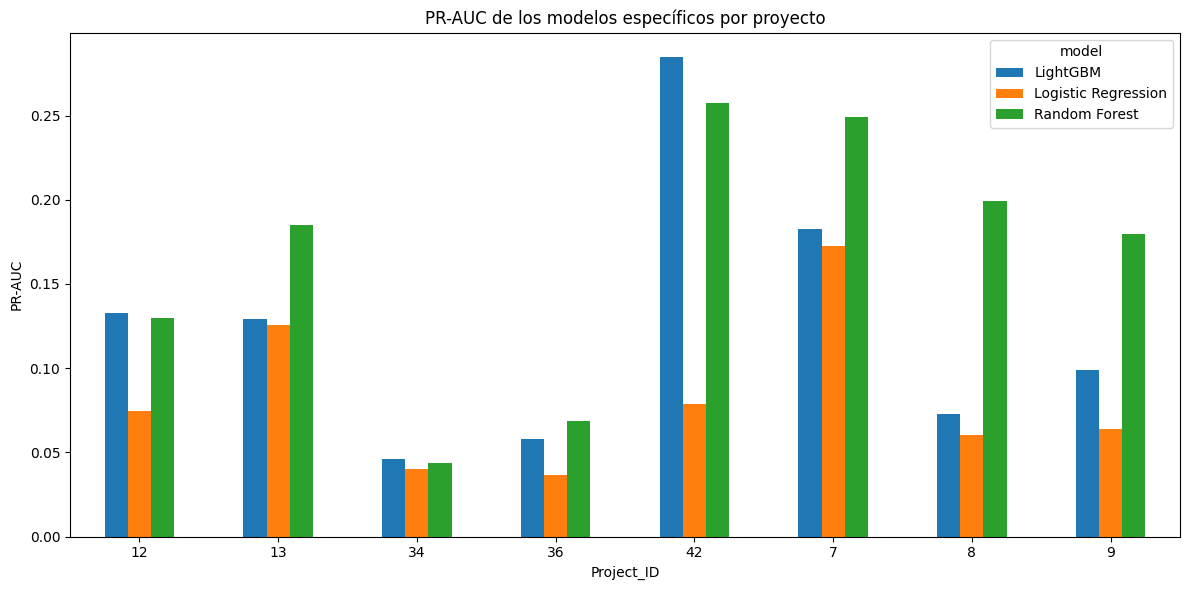

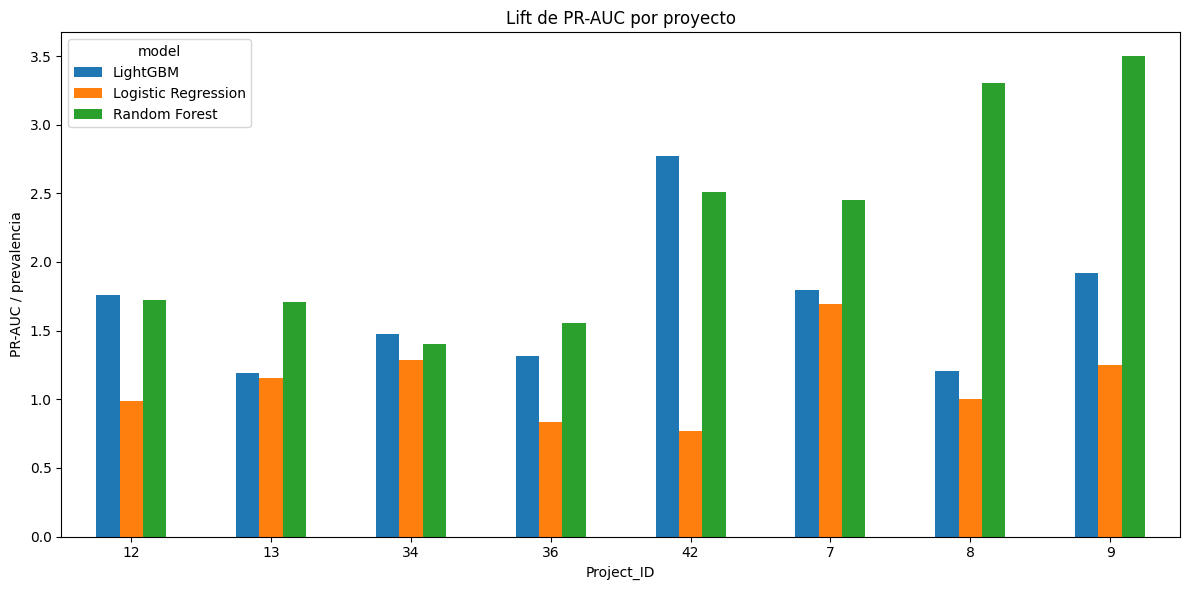

In [17]:
pr_auc_pivot = (
    non_dummy_results
    .pivot(index="Project_ID", columns="model", values="pr_auc")
    .sort_index()
)

pr_auc_pivot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("PR-AUC")
plt.title("PR-AUC de los modelos específicos por proyecto")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

lift_pivot = (
    non_dummy_results
    .pivot(index="Project_ID", columns="model", values="pr_auc_lift")
    .sort_index()
)

lift_pivot.plot(kind="bar", figsize=(12, 6))
plt.ylabel("PR-AUC / prevalencia")
plt.title("Lift de PR-AUC por proyecto")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Comparación directa opcional con el modelo global

El notebook global exporta la evaluación de su mejor modelo por proyecto. La comparación es válida únicamente para los proyectos que conservaron `global_cut`, porque allí ambos modelos se evaluaron sobre los mismos bugs.


In [18]:
GLOBAL_EXPORT_SUFFIX = (
    f"temporal_h180_advanced_logical_imputation_"
    f"{MODELING_VARIANT}"
)

global_project_path = (
    RESULTS_DIR
    / f"project_evaluation_{GLOBAL_EXPORT_SUFFIX}.csv"
)

global_model_results_path = (
    RESULTS_DIR
    / f"model_results_selected_{GLOBAL_EXPORT_SUFFIX}.csv"
)

global_cv_summary_path = (
    RESULTS_DIR
    / f"temporal_cv_summary_{GLOBAL_EXPORT_SUFFIX}.csv"
)

specific_vs_global = pd.DataFrame()

if global_project_path.exists():
    global_project_results = pd.read_csv(global_project_path)
    global_project_results["Project_ID"] = (
        global_project_results["Project_ID"].astype("string")
    )

    best_global_model_name = "Mejor modelo global"

    if global_cv_summary_path.exists():
        global_cv_summary = pd.read_csv(
            global_cv_summary_path
        )
        best_global_model_name = (
            global_cv_summary
            .sort_values(
                [
                    "weighted_pr_auc",
                    "weighted_roc_auc",
                ],
                ascending=False,
            )
            .iloc[0]["model"]
        )
    elif global_model_results_path.exists():
        global_overall_results = pd.read_csv(
            global_model_results_path
        )
        best_global_model_name = (
            global_overall_results.iloc[0]["model"]
        )

    comparable_specific = best_model_by_project.loc[
        best_model_by_project["split_strategy"].eq("global_cut")
    ].copy()
    comparable_specific["Project_ID"] = (
        comparable_specific["Project_ID"].astype("string")
    )

    specific_vs_global = comparable_specific.merge(
        global_project_results[[
            "Project_ID",
            "n",
            "reopened",
            "reopen_rate_pct",
            "pr_auc",
            "roc_auc",
            "precision_at_10pct",
            "recall_at_10pct",
        ]].rename(columns={
            "n": "global_n_test",
            "reopened": "global_positive_test",
            "pr_auc": "global_pr_auc",
            "roc_auc": "global_roc_auc",
            "precision_at_10pct": "global_precision_at_10pct",
            "recall_at_10pct": "global_recall_at_10pct",
        }),
        on="Project_ID",
        how="inner",
        validate="one_to_one",
    )

    specific_vs_global["global_model"] = best_global_model_name
    specific_vs_global["specific_minus_global_pr_auc"] = (
        specific_vs_global["pr_auc"]
        - specific_vs_global["global_pr_auc"]
    )
    specific_vs_global["specific_minus_global_roc_auc"] = (
        specific_vs_global["roc_auc"]
        - specific_vs_global["global_roc_auc"]
    )

    display(specific_vs_global[[
        "Project_ID",
        "global_model",
        "model",
        "n_test",
        "test_prevalence",
        "global_pr_auc",
        "pr_auc",
        "specific_minus_global_pr_auc",
        "global_roc_auc",
        "roc_auc",
        "specific_minus_global_roc_auc",
    ]])
else:
    print(
        "No se encontró la evaluación por proyecto del notebook global. "
        "Ejecute primero el notebook global ADVANCED con imputación lógica y Optuna limpio."
    )


,Project_ID,global_model,model,n_test,test_prevalence,global_pr_auc,pr_auc,specific_minus_global_pr_auc,global_roc_auc,roc_auc,specific_minus_global_roc_auc
0,12,LightGBM,LightGBM,3639,0.075295,0.186600,0.132741,-0.053860,0.769949,0.666866,-0.103083
1,13,LightGBM,Random Forest,360,0.108333,0.182637,0.185251,0.002614,0.652448,0.567857,-0.084591
2,34,LightGBM,LightGBM,6100,0.031148,0.045871,0.046007,0.000136,0.569178,0.565784,-0.003394
3,36,LightGBM,Logistic Regression,1596,0.043860,0.076346,0.036730,-0.039615,0.626137,0.438682,-0.187456
4,42,LightGBM,Random Forest,1392,0.102730,0.249859,0.257471,0.007612,0.764545,0.795792,0.031247
5,7,LightGBM,LightGBM,108,0.101852,0.205960,0.182577,-0.023384,0.513590,0.652296,0.138707
6,9,LightGBM,Random Forest,175,0.051429,0.152317,0.179887,0.027571,0.714190,0.580321,-0.133869


## 11. Importancias y errores

Las tablas permiten analizar si los proyectos dependen de señales distintas. Deben interpretarse dentro de cada modelo y proyecto, no comparando directamente magnitudes de importancia entre algoritmos diferentes.


In [19]:
logistic_coefficients_by_project = (
    pd.concat(all_logistic_coefficients, ignore_index=True)
    if all_logistic_coefficients else pd.DataFrame()
)
rf_importance_by_project = (
    pd.concat(all_rf_importances, ignore_index=True)
    if all_rf_importances else pd.DataFrame()
)
lgbm_importance_by_project = (
    pd.concat(all_lgbm_importances, ignore_index=True)
    if all_lgbm_importances else pd.DataFrame()
)
lgbm_unknown_categories_by_project = (
    pd.concat(all_lgbm_unknown_audits, ignore_index=True)
    if all_lgbm_unknown_audits else pd.DataFrame()
)
optuna_trials_by_project = (
    pd.concat(all_optuna_trials, ignore_index=True)
    if all_optuna_trials else pd.DataFrame()
)
lgbm_candidates_by_project = (
    pd.concat(all_candidate_results, ignore_index=True)
    if all_candidate_results else pd.DataFrame()
)

if not lgbm_importance_by_project.empty:
    top_lgbm_features = (
        lgbm_importance_by_project
        .sort_values(
            ["Project_ID", "importance_gain"],
            ascending=[True, False],
        )
        .groupby("Project_ID", observed=True)
        .head(15)
    )
    display(top_lgbm_features)

if not project_run_errors.empty:
    print("Errores u omisiones registrados")
    display(project_run_errors)
else:
    print("No se registraron errores ni omisiones.")


,Project_ID,feature,importance_split,importance_gain
0,12,description_text_length,756,3219.502049
1,12,project_reopen_events_last_180d,219,3061.880453
2,12,Priority_At_First_Resolution,648,3042.420211
3,12,resolver_previous_resolutions_in_project,696,2814.657101
4,12,title_length,739,2499.908646
5,12,assignee_previous_resolved_bugs_in_project,606,2385.070167
6,12,resolution_time_days,353,2243.177938
7,12,comment_text_avg_length_until_resolution,580,2117.516349
8,12,hours_first_comment_to_resolution,531,2068.003338
9,12,hours_last_comment_to_resolution,466,2067.944740


No se registraron errores ni omisiones.


## 12. Exportación

Los archivos se guardan con el sufijo `temporal_h180_by_project` y no sobrescriben los resultados del modelo global ni los de la validación estratificada.


In [20]:
EXPORT_SUFFIX = (
    f"temporal_h180_by_project_logical_imputation_v2_"
    f"{MODELING_VARIANT}"
)

exports = {
    f"project_model_results_{EXPORT_SUFFIX}.csv": project_model_results,
    f"project_best_models_{EXPORT_SUFFIX}.csv": best_model_by_project,
    f"project_model_aggregate_{EXPORT_SUFFIX}.csv": (
        project_model_aggregate_summary
    ),
    f"project_split_audit_{EXPORT_SUFFIX}.csv": project_split_audit,
    f"project_cv_results_{EXPORT_SUFFIX}.csv": project_cv_results,
    f"project_cv_summary_{EXPORT_SUFFIX}.csv": project_cv_summary,
    f"project_cv_audit_{EXPORT_SUFFIX}.csv": project_cv_audit,
    f"project_test_predictions_{EXPORT_SUFFIX}.csv": (
        project_test_predictions
    ),
    f"project_feature_audit_{EXPORT_SUFFIX}.csv": project_feature_audit,
    f"project_run_errors_{EXPORT_SUFFIX}.csv": project_run_errors,
    f"logistic_coefficients_{EXPORT_SUFFIX}.csv": (
        logistic_coefficients_by_project
    ),
    f"random_forest_importance_{EXPORT_SUFFIX}.csv": (
        rf_importance_by_project
    ),
    f"lightgbm_importance_{EXPORT_SUFFIX}.csv": (
        lgbm_importance_by_project
    ),
    f"lightgbm_unknown_categories_{EXPORT_SUFFIX}.csv": (
        lgbm_unknown_categories_by_project
    ),
    f"optuna_trials_{EXPORT_SUFFIX}.csv": optuna_trials_by_project,
    f"lightgbm_candidates_{EXPORT_SUFFIX}.csv": (
        lgbm_candidates_by_project
    ),
}

if not specific_vs_global.empty:
    exports[f"specific_vs_global_{EXPORT_SUFFIX}.csv"] = (
        specific_vs_global
    )

for filename, frame in exports.items():
    if isinstance(frame, pd.DataFrame):
        frame.to_csv(
            RESULTS_DIR / filename,
            index=False,
            encoding="utf-8-sig",
        )

params_path = RESULTS_DIR / f"best_params_{EXPORT_SUFFIX}.json"
with open(params_path, "w", encoding="utf-8") as file:
    json.dump(
        best_params_by_project,
        file,
        ensure_ascii=False,
        indent=2,
        default=str,
    )

experiment_metadata = {
    "project_experiment_version": PROJECT_EXPERIMENT_VERSION,
    "global_export_suffix": GLOBAL_EXPORT_SUFFIX,
    "modeling_variant": MODELING_VARIANT,
    "target": TARGET_COL,
    "horizon_days": HORIZON_DAYS,
    "temporal_gap_days": TEMPORAL_GAP_DAYS,
    "global_test_start_date": str(GLOBAL_TEST_START_DATE),
    "global_development_end_date": str(GLOBAL_DEVELOPMENT_END_DATE),
    "rf_trials_per_project": RF_N_TRIALS_PER_PROJECT,
    "lgbm_trials_per_project": LGBM_N_TRIALS_PER_PROJECT,
    "projects": [str(value) for value in project_ids],
    "base_temporal_fold_weights": (
        BASE_TEMPORAL_FOLD_WEIGHTS.tolist()
    ),
    "selection_metric": "weighted_pr_auc",
    "logical_temporal_imputation": True,
    "logical_imputation_scope": "fit_within_each_project_fold",
}

with open(
    RESULTS_DIR / f"experiment_metadata_{EXPORT_SUFFIX}.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        experiment_metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

print("Resultados exportados en:", RESULTS_DIR)


Resultados exportados en: /app/output/modeling_results


## 13. Criterios de interpretación

- El modelo temporal global sigue siendo el análisis principal porque utiliza toda la información histórica disponible y representa una única herramienta aplicable a los proyectos seleccionados.
- Los modelos específicos permiten evaluar la heterogeneidad entre proyectos y determinar si la adaptación al workflow local compensa la pérdida de tamaño muestral.
- Una mejora del modelo específico solo puede atribuirse al enfoque por proyecto cuando ambos fueron evaluados sobre el mismo test (`global_cut`).
- En los proyectos con `project_specific_cut`, la comparación válida es entre los tres algoritmos específicos dentro de ese proyecto.
- La PR-AUC debe interpretarse junto con la prevalencia y con `pr_auc_lift`.
- `precision_at_10pct` y `recall_at_10pct` evalúan la capacidad de concentrar reaperturas en el grupo de bugs que recibiría una revisión adicional.
- Los proyectos con pocos positivos o con un único fold temporal deben presentarse con cautela, porque sus métricas tienen mayor variabilidad.
- No se imputa ningún faltante: LightGBM utiliza su manejo nativo y los otros dos modelos excluyen las cuatro variables incompletas autorizadas.

- La optimización avanzada con 80 trials y ensamble de semillas se reserva para el modelo global; varios proyectos poseen pocos positivos o un único fold y no permiten una búsqueda estable de igual complejidad.
